# Import and setup

In [32]:
import os
from pathlib import Path
import glob
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import scipy
from scipy.cluster.hierarchy import fcluster
import string
from scipy.stats import spearmanr, pearsonr



In [3]:
# negative controls
negctrls_fpath = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/Ciber2_iii/CZB_Sep2024/neg_controls.csv'
neg_controls_df = pd.read_csv(negctrls_fpath, usecols=['DNAseq'])
neg_controls = neg_controls_df['DNAseq'].to_list() # list of all negative controls
neg_controls[:5]

['GATGCTTTGTCTTCTTCTTCTTTGCCATCTACTGCTGTTGCTCAAGGTGATATTCAAACTACTTCTACTGCTGATACTGAAACTAAAAATCCAGCTCAATCTGATATTGCTGAAGCTGCT',
 'TCTTCTTTGCCATCTACTGCTGTTGCTCAAGGTGATATTCAAACTACTTCTACTGCTGATACTGAAACTAAAAATCCAGCTCAATCTGATATTGCTGAAGCTGCTAGACAATTGTTGGAA',
 'TTGAATGCTTATAGAGAAAAAGGTGGTTGTGTTTTGTTGATTCATAGAGATACTAAACAAGTTGTTGAATATTTGTTGCAAGATAAAACTAGACCAGCTTATAGAGAAGATATTGAAGAT',
 'GCTTTGCATAATACTTTGTTTCAATTGACTGGTTTGCCACATTCTTATTCTGCTGTTGAAACTGATCAAGCTGAACCAACTGTTAGAGAATTGACTAGAAGAGCTGATTTTGGTGGTGCT',
 'GCTCCAGCTCCACAACCATCTCCAGTTCAAAAACCAGTTGAAACTGAAGTTGCTGTTACTACTACTTCTTCTTCTTCTAGAAGAAAATCTGGTGGTTCTCCAGCTTCTGGTAGACATTCT']

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Database & Untransformed data setup (Run only once)

In [28]:
ec_lookup = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/A10_sequencing/v2/current/analysis2_updated.db'
save_db_to = 'post_merge.db'
patterns = [
    # "1_0", "1_5", 
    "1_10", "1_15", "1_30", "1_180", "1_240",
    "2_0", "2_5", "2_10", "2_15", "2_30", "2_180", "2_240",
    "3_0", "3_5", "3_10", "3_15", "3_30", "3_180", "3_240"
]

In [4]:
def bc_grouping(db_path, is_rptr=True):
    try:
        conn = duckdb.connect(db_path)
        print('connected to db')
        if is_rptr:
            group_query = f"""
                SELECT Barcode, COUNT(DISTINCT UMI) AS UMIs, SUM(Count) AS Reads
                FROM umi_counts
                GROUP BY Barcode
            """
            new_table = "rptr_summary"
        else:
            group_query = f"""
                SELECT Barcode, Tile, COUNT(DISTINCT UMI) AS UMIs, SUM(Count) AS Reads
                FROM umi_counts
                GROUP BY Barcode, Tile
            """
            new_table = "ad_summary"

        conn.execute(f"CREATE OR REPLACE TABLE {new_table} AS {group_query}")
        print('summary table created')
        row_count = conn.execute(f"SELECT COUNT(*) FROM {new_table}").fetchone()[0]
        print(f"[GROUP] Wrote {row_count} rows to {new_table} in {db_path}")

    except Exception as e:
        print(f"[ERROR] While filtering and grouping {db_path}: {e}")

    finally:
        conn.close()


def perform_lookup(rptr_db_path, lookup_db_path):
    try:
        rptr_conn = duckdb.connect(rptr_db_path)
        rptr_conn.execute(f"ATTACH DATABASE '{lookup_db_path}' AS lookup_db")

        total_rptr_barcodes = rptr_conn.execute("SELECT COUNT(*) FROM rptr_summary").fetchone()[0]

        rptr_conn.execute("""
            CREATE OR REPLACE TABLE rptr_lookup_joined AS
            SELECT 
                r.Barcode, r.UMIs, r.Reads,
                l.AD,
                l.AD_BC,
                l.AD || '-' || l.AD_BC AS AD_ADBC
            FROM rptr_summary r
            INNER JOIN lookup_db.A10_2_T_NODBLMAP_20240422 l
            ON r.Barcode = l.RPTR_BC;
        """)

        matched_count = rptr_conn.execute("SELECT COUNT(*) FROM rptr_lookup_joined").fetchone()[0]
        print(f"[LOOKUP JOIN] Matched {matched_count} of {total_rptr_barcodes} RPTR barcodes "
              f"({total_rptr_barcodes - matched_count} unmatched, discarded in join).")

    except Exception as e:
        print(f"[ERROR] During lookup join in {rptr_db_path}: {e}")

    finally:
        rptr_conn.close()


def join_rptr_ad(rptr_db, ad_db, output_db, out_table):
    try:
        conn_out = duckdb.connect(output_db)

        # Attach RPTR and AD databases
        conn_out.execute(f"ATTACH DATABASE '{rptr_db}' AS rptr_db")
        conn_out.execute(f"ATTACH DATABASE '{ad_db}' AS ad_db")

        # Perform join and save
        conn_out.execute(f"""
            CREATE OR REPLACE TABLE {out_table} AS
            SELECT 
                r.Barcode AS RPTR_BC,
                r.UMIs AS RPTR_UMIs,
                r.Reads AS RPTR_Reads,
                a.Barcode AS AD_BC,
                a.Tile,
                a.UMIs AS AD_UMIs,
                a.Reads AS AD_Reads
            FROM rptr_db.rptr_lookup_joined r
            INNER JOIN ad_db.ad_summary a
            ON r.AD_ADBC = a.Tile || '-' || a.Barcode;
        """)

        joined_count = conn_out.execute(f"SELECT COUNT(*) FROM {out_table}").fetchone()[0]
        print(f"[JOIN FINAL] Joined entries: {joined_count}")

    except Exception as e:
        print(f"[ERROR] During final join: {e}")

    finally:
        conn_out.close()



In [9]:
rptr_dir = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/RPTR_UMIdemultiplexed'
ad_dir = '/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/AD_UMIdemultiplexed'
merged_dfs = {}
for pattern in patterns:
    print(pattern)
    rptr_db_ec = glob.glob(f"{rptr_dir}/RPTR_{pattern}_S*_R1_001.duckdb")[0]
    ad_db_ec = f"{ad_dir}/AD_{pattern}.fastq.gz.assembled.fastq.duckdb"
    save_table_as = f'merged_{pattern}'

    # create databases
    bc_grouping(rptr_db_ec, is_rptr=True) # creates rptr_summary
    bc_grouping(ad_db_ec, is_rptr=False) # creates ad_summary
    perform_lookup(rptr_db_ec, ec_lookup) # creates rptr_lookup_joined
    join_rptr_ad(rptr_db_ec, ad_db_ec, save_db_to, save_table_as) # creates/opens database (save_db_to = 'post_merge.db') and saves that time point/sample as save_table_as = f'merged_{pattern}'

    if glob.glob(save_db_to):
        conn = duckdb.connect(save_db_to)
        df = conn.sql(f"SELECT * FROM {save_table_as}").df()
        df['Ratio'] = df['RPTR_UMIs'] / df['AD_UMIs']
        neg_control_mean = df[df['Tile'].isin(neg_controls)]['Ratio'].mean()
        df['Ratio_negctrlnorm'] = df['Ratio']/neg_control_mean
        merged_dfs[pattern] = df
        conn.close()
        

1_10
connected to db
summary table created
[GROUP] Wrote 3102262 rows to rptr_summary in /global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/RPTR_UMIdemultiplexed/RPTR_1_10_S3_R1_001.duckdb
connected to db
summary table created
[GROUP] Wrote 3232539 rows to ad_summary in /global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/AD_UMIdemultiplexed/AD_1_10.fastq.gz.assembled.fastq.duckdb
[LOOKUP JOIN] Matched 18515 of 3102262 RPTR barcodes (3083747 unmatched, discarded in join).
[JOIN FINAL] Joined entries: 16521
1_15
connected to db
summary table created
[GROUP] Wrote 2783623 rows to rptr_summary in /global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/RPTR_UMIdemultiplexed/RPTR_1_15_S4_R1_001.duckdb
connected to db
summary table created
[GROUP] Wrote 2761835 rows to ad_summary in /global/scratch/projects/fc_mvslab/OpenProjec

In [11]:
merged_dfs['2_15']

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads,Ratio,Ratio_negctrlnorm
0,ATGCTGTTACAAGC,1,23.0,CTTGTGGCAGA,TCTTCTACTAATATGGATACTGTTTCTCCACAAGATTTGTTGAGAG...,6,63.0,0.166667,1.379659
1,TTAGTCTGTGTATT,670,30251.0,AGTTACGAGTA,AATTTGGCTTCTCCACAATCTTTGTTTGATTCTCCATCTGAATCTT...,28,365.0,23.928571,198.079665
2,GAGACCGATTTCAC,44,1911.0,AATAAAAAAAA,GCTCCATCTGCTTCTCCAGCTCCATCTAGACAAGGTACTAAACATT...,21,49.0,2.095238,17.344289
3,TACCAAGATATAAA,9,587.0,AATGATAGATG,CAAAGGAAGAAGAAAGATCAAACTGGTATTGAAGAAAGAAGATCTC...,8,85.0,1.125000,9.312701
4,CACCCAAGTCCACC,117,4472.0,TTCGGATGGTG,ATTAATGATTTGTTGAATGATGACTTTATTATCTTGCCAGAAACTT...,2,29.0,58.500000,484.260434
...,...,...,...,...,...,...,...,...,...
16572,TTCTTTTCGGTTTG,309,12898.0,CCCGCGAAGCA,TCTTCTGGTTACTTCTCTCATGATACTTCTCCATTGTTTGCTGATG...,20,236.0,15.450000,127.894422
16573,CAGTACCTTTCTGT,1,2.0,CCGGTTAACTG,TTGAATAATGCTTCTAGATCTTCTTCTTCTTCTGCTTTGACTATTT...,15,247.0,0.066667,0.551864
16574,ACCATTGTAATAAA,4,176.0,TTACAGGTTAA,AGATCTTATTATCAACATTCTCATATGTTGACTCATGTTGCTGATT...,13,164.0,0.307692,2.547063
16575,CCGAGGCGTCTTGT,10,206.0,GTTCTCCTTAC,AGGAAATCTTCTGTTACTAATTCTCCAGCTACTAATGGTATTTCTA...,13,157.0,0.769231,6.367659


### Database Checks

In [29]:
conntest = duckdb.connect(save_db_to)
conntest.sql("SHOW ALL TABLES")

┌────────────┬─────────┬──────────────┬──────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────┬───────────┐
│  database  │ schema  │     name     │                           column_names                           │                         column_types                          │ temporary │
│  varchar   │ varchar │   varchar    │                            varchar[]                             │                           varchar[]                           │  boolean  │
├────────────┼─────────┼──────────────┼──────────────────────────────────────────────────────────────────┼───────────────────────────────────────────────────────────────┼───────────┤
│ post_merge │ main    │ merged_1_0   │ [RPTR_BC, RPTR_UMIs, RPTR_Reads, AD_BC, Tile, AD_UMIs, AD_Reads] │ [VARCHAR, BIGINT, HUGEINT, VARCHAR, VARCHAR, BIGINT, HUGEINT] │ false     │
│ post_merge │ main    │ merged_1_10  │ [RPTR_BC, RPTR_UMIs, RPTR_Reads, AD_BC, Tile,

In [32]:
merged_2_15_df = conntest.sql("SELECT * FROM merged_2_15").df()
merged_2_15_df

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads
0,ATGCTGTTACAAGC,1,23.0,CTTGTGGCAGA,TCTTCTACTAATATGGATACTGTTTCTCCACAAGATTTGTTGAGAG...,6,63.0
1,TTAGTCTGTGTATT,670,30251.0,AGTTACGAGTA,AATTTGGCTTCTCCACAATCTTTGTTTGATTCTCCATCTGAATCTT...,28,365.0
2,GAGACCGATTTCAC,44,1911.0,AATAAAAAAAA,GCTCCATCTGCTTCTCCAGCTCCATCTAGACAAGGTACTAAACATT...,21,49.0
3,TACCAAGATATAAA,9,587.0,AATGATAGATG,CAAAGGAAGAAGAAAGATCAAACTGGTATTGAAGAAAGAAGATCTC...,8,85.0
4,CACCCAAGTCCACC,117,4472.0,TTCGGATGGTG,ATTAATGATTTGTTGAATGATGACTTTATTATCTTGCCAGAAACTT...,2,29.0
...,...,...,...,...,...,...,...
16572,TTCTTTTCGGTTTG,309,12898.0,CCCGCGAAGCA,TCTTCTGGTTACTTCTCTCATGATACTTCTCCATTGTTTGCTGATG...,20,236.0
16573,CAGTACCTTTCTGT,1,2.0,CCGGTTAACTG,TTGAATAATGCTTCTAGATCTTCTTCTTCTTCTGCTTTGACTATTT...,15,247.0
16574,ACCATTGTAATAAA,4,176.0,TTACAGGTTAA,AGATCTTATTATCAACATTCTCATATGTTGACTCATGTTGCTGATT...,13,164.0
16575,CCGAGGCGTCTTGT,10,206.0,GTTCTCCTTAC,AGGAAATCTTCTGTTACTAATTCTCCAGCTACTAATGGTATTTCTA...,13,157.0


Text(0.5, 1.0, 'Post-Merge Reads per RPTR BC')

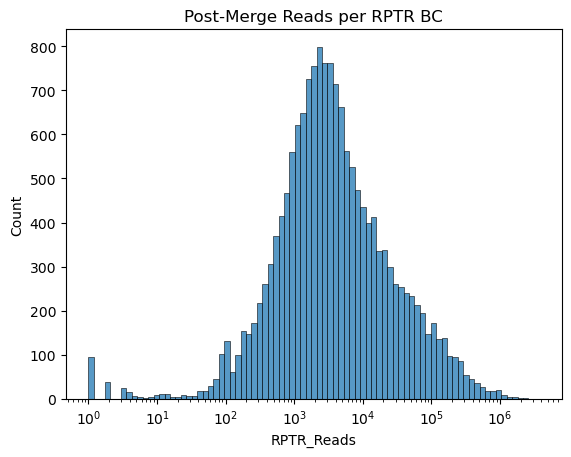

In [34]:
sns.histplot(merged_2_15_df, x='RPTR_Reads', log_scale=True)
plt.title('Post-Merge Reads per RPTR BC')

In [35]:
connRtest = duckdb.connect('/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/20250226_TREBL_MAZ06/RPTR_UMIdemultiplexed/RPTR_2_15_S11_R1_001.duckdb')
connRtest.sql("SHOW ALL TABLES")

┌──────────────────────┬─────────┬────────────────────┬────────────────────────────────────────────┬───────────────────────────────────────────────────────┬───────────┐
│       database       │ schema  │        name        │                column_names                │                     column_types                      │ temporary │
│       varchar        │ varchar │      varchar       │                 varchar[]                  │                       varchar[]                       │  boolean  │
├──────────────────────┼─────────┼────────────────────┼────────────────────────────────────────────┼───────────────────────────────────────────────────────┼───────────┤
│ RPTR_2_15_S11_R1_001 │ main    │ rptr_lookup_joined │ [Barcode, UMIs, Reads, AD, AD_BC, AD_ADBC] │ [VARCHAR, BIGINT, HUGEINT, VARCHAR, VARCHAR, VARCHAR] │ false     │
│ RPTR_2_15_S11_R1_001 │ main    │ rptr_summary       │ [Barcode, UMIs, Reads]                     │ [VARCHAR, BIGINT, HUGEINT]                            

In [43]:
RPTR_2_15_SAMPLE_df = connRtest.sql("SELECT * FROM rptr_summary where random() <= 0.1").df()
RPTR_2_15_SAMPLE_df

,Barcode,UMIs,Reads
0,CCAAAGGGGGCGAG,4,4.0
1,ACCAGCTCTCTTAA,28,1297.0
2,ATGAGTAGATGAAC,2360,96704.0
3,TCACTGCCTCTGCG,56,2498.0
4,GGGGGGGGTTGGAT,5,5.0
...,...,...,...
362052,ACGGGTAGATAAGT,1,1.0
362053,GCATTATGACTATA,1,1.0
362054,GAGCAGTGCCTGGG,1,1.0
362055,TTCACATGGATAAT,1,1.0


(0.0, 1000.0)

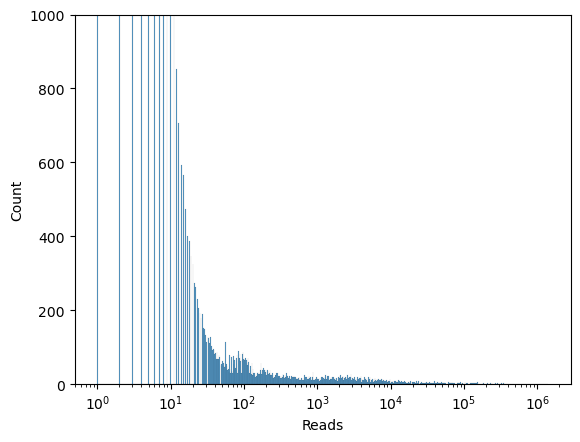

In [45]:
sns.histplot(RPTR_2_15_SAMPLE_df, x='Reads', log_scale=True)
plt.ylim(0,1000)

## Putting the data together

In [12]:
# combine by time point ?

t0 = []
t5 = []
t10 = []
t15 = []
t30 = []
t180 = []
t240 = []

for key in merged_dfs.keys():
    if key.endswith('_5'):
        # print(key)
        merged_dfs[key]['Library'] = key
        t5.append(merged_dfs[key])
    if key.endswith('_10'):
        # print(key)
        merged_dfs[key]['Library'] = key
        t10.append(merged_dfs[key])
    if key.endswith('_15'):
        # print(key)
        merged_dfs[key]['Library'] = key
        t15.append(merged_dfs[key])  
    if key.endswith('_30'):
        # print(key)
        merged_dfs[key]['Library'] = key
        t30.append(merged_dfs[key])
    if key.endswith('_180'):
        # print(key)
        merged_dfs[key]['Library'] = key
        t180.append(merged_dfs[key])
    if key.endswith('_240'):
        # print(key)
        merged_dfs[key]['Library'] = key
        t240.append(merged_dfs[key])      
    if key.endswith('_0'):
        # print(key)
        merged_dfs[key]['Library'] = key
        t0.append(merged_dfs[key])    
        
t5_all = pd.concat(t5, ignore_index=True)

t10_all = pd.concat(t10, ignore_index=True)

t15_all = pd.concat(t15, ignore_index=True)

t30_all = pd.concat(t30, ignore_index=True)

t180_all = pd.concat(t180, ignore_index=True)

t240_all = pd.concat(t240, ignore_index=True)

t0_all = pd.concat(t0, ignore_index=True)


# print(t10_all.head())
t10_all.head()

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads,Ratio,Ratio_negctrlnorm,Library
0,GCCGAAGTACGTTT,204,10935.0,GCCTGAGGGCC,ACTATTTCTCCTAAAGATTTGTTGAATGATTCTGCTCCACCATCTA...,330,3575.0,0.618182,5.911857,1_10
1,TAAGCTCTGCCATG,83,3667.0,GTCTAGAATTA,ACTTCTAGATCTACTACTAAACATTCTACTGTTGCTGGTGTTTCTG...,687,6796.0,0.120815,1.155391,1_10
2,GTATACAAATGACA,4883,252390.0,TTCGGTTTAGG,AATTTGCAAGATCAAAGAACTACTAATATGTCTAGACCAACATTTC...,1108,10232.0,4.407040,42.145834,1_10
3,TCCAACCATTGGCT,1842,86160.0,GTCTAAATCGG,TGTGGTACTACTGTTTCTCCATCTGAAGTTACTATGAATCCATCTA...,770,8002.0,2.392208,22.877396,1_10
4,AGTCGATCTCTGGT,114,6161.0,TAATATTTCCG,CAACCATCTCATCAAGACTTTGTCTTGTTTGAAAGATCTCCATCTG...,708,6831.0,0.161017,1.539853,1_10


In [13]:
time_df_list = [t0_all, t5_all, t10_all, t15_all, t30_all, t180_all, t240_all]

In [15]:
concatenated_df = pd.concat(time_df_list, ignore_index=True)
concatenated_df['Time'] = concatenated_df['Library'].str.split('_').str[-1]
concatenated_df['Time'] = pd.to_numeric(concatenated_df['Time'])
concatenated_df['sample'] = concatenated_df['Library'].str.split('_').str[-2]
concatenated_df.head()

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads,Ratio,Ratio_negctrlnorm,Library,Time,sample
0,CTTGTTGGATCAAA,2,720.0,ATCGATCCGAA,TGGTATTCTTTGTTTCCACCAACTACTACTTCTTCTGAAGATTCTC...,9,87.0,0.222222,1.054749,2_0,0,2
1,CTGACGAATCGTAC,2,96.0,ACTATGTGTTA,GCTGCTGTTTCTACTAAATTGGAAGCTCCAGCTACTACTCATTTGA...,14,121.0,0.142857,0.678053,2_0,0,2
2,CGACAAGAGTGATT,29,2709.0,GGACGCACACG,ATGACATTTGATTCTTCTAATTTGAATGCTGCTCCAGCTTCTTCTG...,7,70.0,4.142857,19.663531,2_0,0,2
3,GTGGCAATAACGGA,1,18.0,CATGATAGGTC,ATTGAAAGAGATGCTAGAAGAGAATGTTGTGCTCCACAATCTAATT...,4,39.0,0.250000,1.186592,2_0,0,2
4,GAGCATCCAGACGA,48,4093.0,CCTCGACATAG,CATTCTTCTTTGAGACCATCTGATGAAGCTTGTCCATTGTCTACTG...,2,3.0,24.000000,113.912870,2_0,0,2


In [18]:
concatenated_df.to_csv('rawdata_UMIs_normalized_20250415.csv')

# Transform the data

In [5]:
# if starting here
concatenated_df = pd.read_csv('rawdata_UMIs_normalized_20250415.csv', index_col=0)

In [6]:
# read in facs csv with activity data and control designation (EC did by hand in excel)
facs_f='/global/scratch/projects/fc_mvslab/OpenProjects/EChase/TREBLEseq_ismaybethenewcibername/Ciber2_iii/CZB_Sep2024/Gcn4OrthologData_ToShare_20230414_EC.csv'
facsdf = pd.read_csv(facs_f, usecols=['Name','ArrayDNA','is_control',]).dropna()

# inner join the df's 
intersectiondf = pd.merge(concatenated_df, facsdf,
                   left_on = 'Tile', right_on = 'ArrayDNA',
                   how= 'inner')
intersectiondf = intersectiondf.drop(columns=['ArrayDNA', ])
intersectiondf

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads,Ratio,Ratio_negctrlnorm,Library,Time,sample,Name,is_control
0,CTTGTTGGATCAAA,2,720.0,ATCGATCCGAA,TGGTATTCTTTGTTTCCACCAACTACTACTTCTTCTGAAGATTCTC...,9,87.0,0.222222,1.054749,2_0,0,2,Pezizomycetes_jgi|Geocar1|601711|gw1.55.41.1_51,experimental
1,CTGACGAATCGTAC,2,96.0,ACTATGTGTTA,GCTGCTGTTTCTACTAAATTGGAAGCTCCAGCTACTACTCATTTGA...,14,121.0,0.142857,0.678053,2_0,0,2,Blastocladiomycota_jgi|Catan2|1466814|fgenesh1...,experimental
2,CGACAAGAGTGATT,29,2709.0,GGACGCACACG,ATGACATTTGATTCTTCTAATTTGAATGCTGCTCCAGCTTCTTCTG...,7,70.0,4.142857,19.663531,2_0,0,2,Sordariomycetes_jgi|OphPMI507_1|434063|gm1.879...,experimental
3,GTGGCAATAACGGA,1,18.0,CATGATAGGTC,ATTGAAAGAGATGCTAGAAGAGAATGTTGTGCTCCACAATCTAATT...,4,39.0,0.250000,1.186592,2_0,0,2,Pezizomycetes_jgi|Sphbr2|1027810|estExt_fgenes...,experimental
4,GAGCATCCAGACGA,48,4093.0,CCTCGACATAG,CATTCTTCTTTGAGACCATCTGATGAAGCTTGTCCATTGTCTACTG...,2,3.0,24.000000,113.912870,2_0,0,2,Sordariomycetes_jgi|Verdah1|127083|CE127082_16...,experimental
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315187,CTCAGTGTGAGTGT,9,152.0,CCGTGCCCCCG,TCTGATAATTCTAATCCATTGAATGCTTCATTCTTGATTCCACAAT...,8,139.0,1.125000,1.517782,3_240,240,3,Saccharomycotina_jgi|Yarlip1|154613|estExt_fge...,experimental
315188,CACTCCCGTGTTTC,729,13930.0,TCTTTCCTCCG,GTTGTTACTACTTCTGCTGTTGTTACTACTTCTGCTGCTTCTCAAG...,4,33.0,182.250000,245.880634,3_240,240,3,Sordariomycetes_jgi|Daces1|604900|estExt_fgene...,experimental
315189,TAACAAATTATGGC,3,14.0,CAGGTTCAGAG,GATTATTCTCCATTGACTGGTGTTCATGATACTTCTTCTCCATCTA...,3,13.0,1.000000,1.349139,3_240,240,3,Pezizomycetes_jgi|Chove1|1732154|estExt_Genewi...,experimental
315190,GTATCAACCACCAC,739,14493.0,GCCTTCACCCG,CCACCACAACCAACTGCTCAGAATTTAAATTCTAATAATGATAATA...,2,6.0,369.500000,498.506964,3_240,240,3,Eurotiomycetes_jgi|Asptam1|301894|gm1.7538_g_226,experimental


### Interlude April 16, 2025: are the things in the dataset the same as the gcn4 ortholog evolution dataset

In [6]:
intersectiondf['RPTR_BC'].value_counts().to_frame().reset_index()

,RPTR_BC,count
0,CTCACCCGGTGAAA,62
1,AGAAGCACCTAATG,38
2,CCGCTAAGCCTCGG,38
3,CATAGGTATCATTC,38
4,AGGGGTGCATAAGC,38
...,...,...
17689,TAATCTGCGAAAAG,1
17690,GAGCCCTTCTTGGA,1
17691,TATTCACATAGAAT,1
17692,CTAAACAAGTTGAA,1


In [7]:
intersectiondf[intersectiondf.isna().any(axis=1)]

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads,Ratio,Ratio_negctrlnorm,Library,Time,sample,Name,is_control


## interlude over

In [7]:
# Define a function to remove outliers using the IQR method for each time group
def remove_outliers(df, group_col, target_col):
    """
    Distribution is non-parametric (skewed to the left, see lab notebook November 19, 2024), so we will keep the IQR method for calculating outliers
    """
    def filter_outliers(group):
        q1 = group[target_col].quantile(0.25) #finding IQR
        q3 = group[target_col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr # establish bounds of IQR
        upper_bound = q3 + 1.5 * iqr
        return group[(group[target_col] >= lower_bound) & (group[target_col] <= upper_bound)] # for a group return only those that are within IQR

    return df.groupby(group_col, group_keys=False)[['Tile','sample','Name', target_col, 'Time', 'RPTR_BC', 'Ratio']].apply(filter_outliers) # group by a column, find IQR, return non-outliers

In [8]:
def tile_and_replicate_hillfxn(tile, scoretype, outliers_removed=True, save_fig=False):
    """
    Generate subplots for:
    1. Ratio vs. Time for a single sample, showing individual replicates (RPTR_BC) with their mean and standard deviation.
    2. Ratio vs. Time for multiple samples, showing individual sample lines with overall mean and standard deviation.
    
    Parameters:
    tile (str): The tile to plot.
    outliers_removed (bool): Whether to remove outliers (based on IQR).
    """
    tiledf = intersectiondf.copy(deep=True)
    single_sample_df1 = tiledf[(tiledf['Tile'] == tile) & (tiledf['sample'] == 1)]
    single_sample_df2 = tiledf[(tiledf['Tile'] == tile) & (tiledf['sample'] == 2)]
    single_sample_df3 = tiledf[(tiledf['Tile'] == tile) & (tiledf['sample'] == 3)]
    
    all_samples_df = tiledf[tiledf['Tile'] == tile]
    tile_name = next(iter(set(all_samples_df['Name'].to_list())))
    
    if outliers_removed:
        single_sample_df1 = remove_outliers(single_sample_df1, group_col='Time', target_col=scoretype)
        single_sample_df2 = remove_outliers(single_sample_df2, group_col='Time', target_col=scoretype)
        single_sample_df3 = remove_outliers(single_sample_df3, group_col='Time', target_col=scoretype)
        all_samples_df = remove_outliers(all_samples_df, group_col='Time', target_col=scoretype)
    
    replicate_means1 = single_sample_df1.groupby(['Time', 'RPTR_BC'])[scoretype].mean().reset_index()
    replicate_means2 = single_sample_df2.groupby(['Time', 'RPTR_BC'])[scoretype].mean().reset_index()
    replicate_means3 = single_sample_df3.groupby(['Time', 'RPTR_BC'])[scoretype].mean().reset_index()
    
    single_time_means2 = single_sample_df1.groupby('Time')[scoretype].agg(['mean', 'std']).reset_index()
    single_time_means3 = single_sample_df2.groupby('Time')[scoretype].agg(['mean', 'std']).reset_index()
    single_time_means4 = single_sample_df3.groupby('Time')[scoretype].agg(['mean', 'std']).reset_index()
    
    sample_means = all_samples_df.groupby(['Time', 'sample'])[scoretype].mean().reset_index()
    all_time_means = sample_means.groupby('Time')[scoretype].agg(['mean', 'std']).reset_index()
    
    unique_bcs = intersectiondf['RPTR_BC'].unique()
    palette = sns.color_palette("tab20", len(unique_bcs))
    bc_color_map = dict(zip(unique_bcs, palette))
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
    fig.suptitle(f'Tile {tile_name}: Ratio (normalized) vs. Time', fontsize=16, fontweight='bold')
    
    for i, (replicate_means, single_time_means, title, ax) in enumerate(
        zip([replicate_means1, replicate_means2, replicate_means3],
            [single_time_means2, single_time_means3, single_time_means4],
            ['Single Sample (Sample 1)', 'Single Sample (Sample 2)', 'Single Sample (Sample 3)'],
            axes[:3])
    ):
        sns.lineplot(data=replicate_means, x='Time', y=scoretype, hue='RPTR_BC', ax=ax, alpha=0.6, lw=1.5, palette=bc_color_map)
        ax.errorbar(single_time_means['Time'], single_time_means['mean'], yerr=single_time_means['std'], fmt='o-', capsize=5, capthick=2, color='black', label='Overall Mean ± Std Dev', lw=2, alpha=0.7)
        ax.set_title(title)
        ax.set_ylabel(f'Ratio (RPTR norm.reads/AD norm.reads) normalized by {scoretype}')
        ax.set_xlabel('Time (min)')
        ax.legend(title='Replicates', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, linestyle='--', alpha=0.3)
    
    sns.lineplot(data=sample_means, x='Time', y=scoretype, hue='sample', ax=axes[3], palette='viridis', alpha=0.85, lw=1.5)
    axes[3].errorbar(all_time_means['Time'], all_time_means['mean'], yerr=all_time_means['std'], fmt='o-', capsize=5, capthick=2, color='red', label='Overall Mean ± Std Dev', lw=2, alpha=0.5)
    axes[3].set_title('All Samples')
    axes[3].set_ylabel(f'Ratio (RPTR norm.reads/AD norm.reads) normalized by {scoretype}')
    axes[3].set_xlabel('Time (min)')
    axes[3].legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[3].grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if save_fig:
        plt.savefig(f'vp16norm_figs/timeseries/{tile_name}_vp16norm.pdf')
    plt.show()
    
    return tile_name, all_time_means['mean']


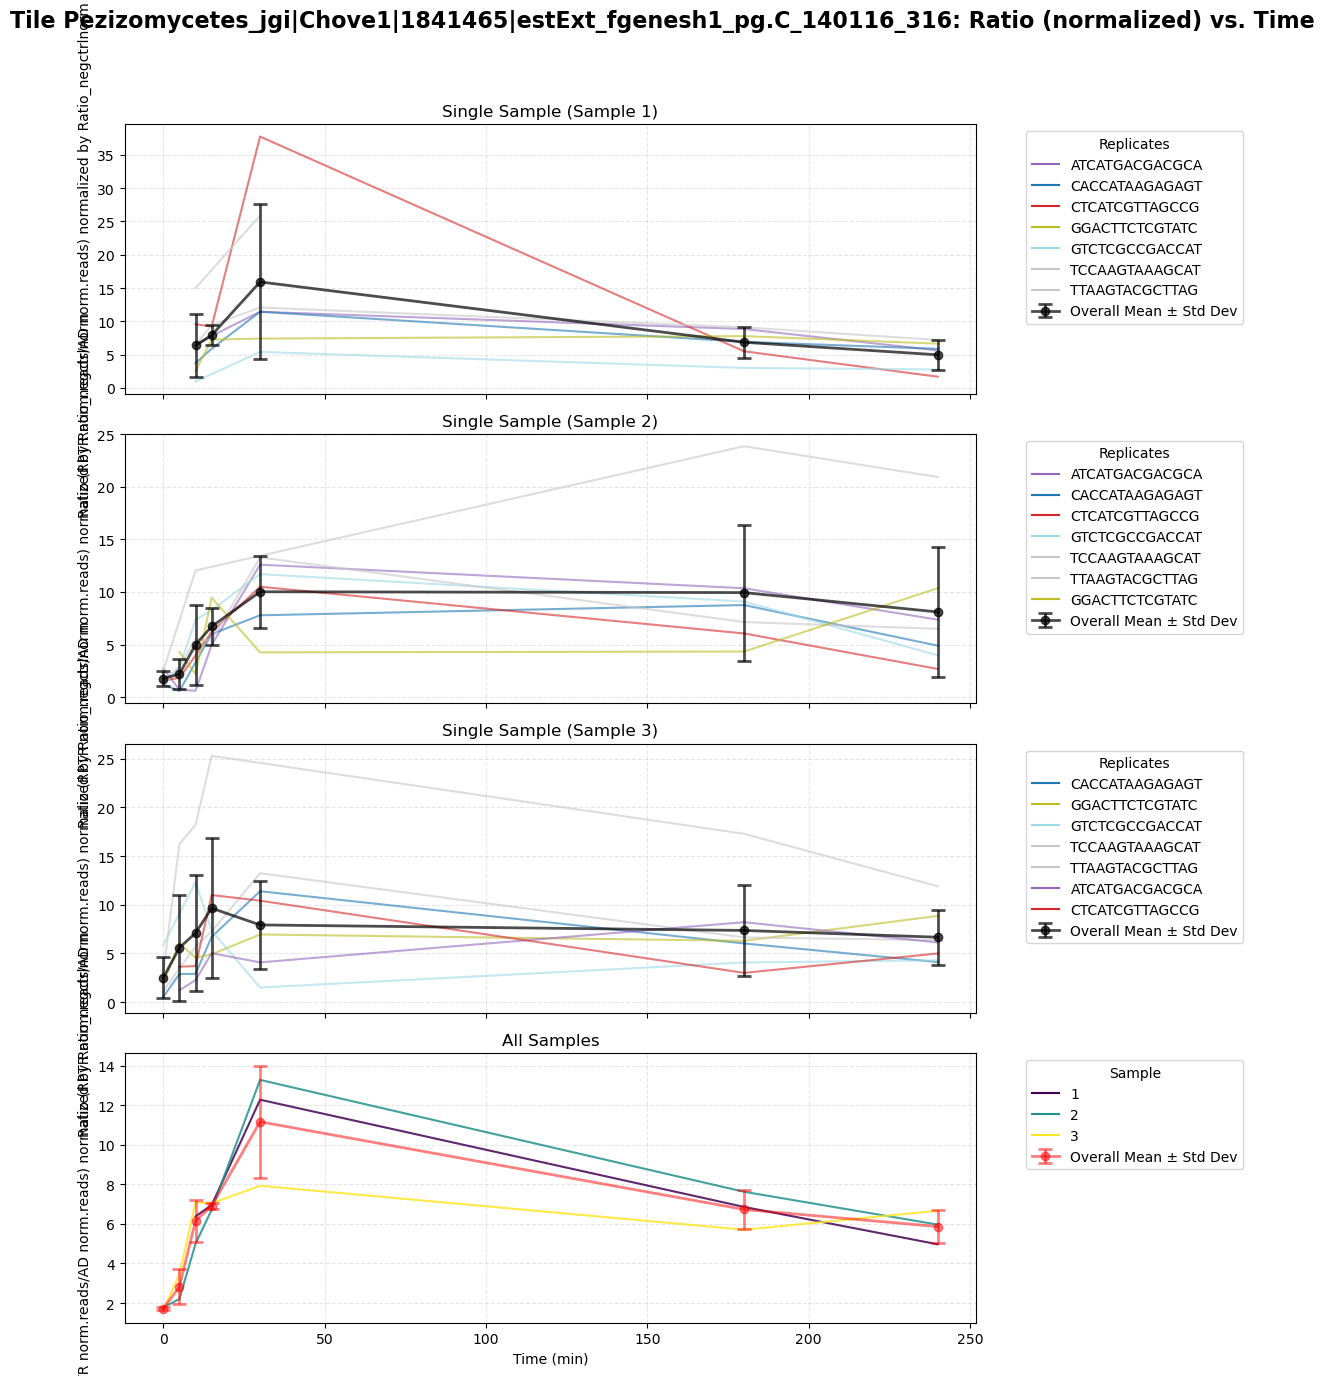

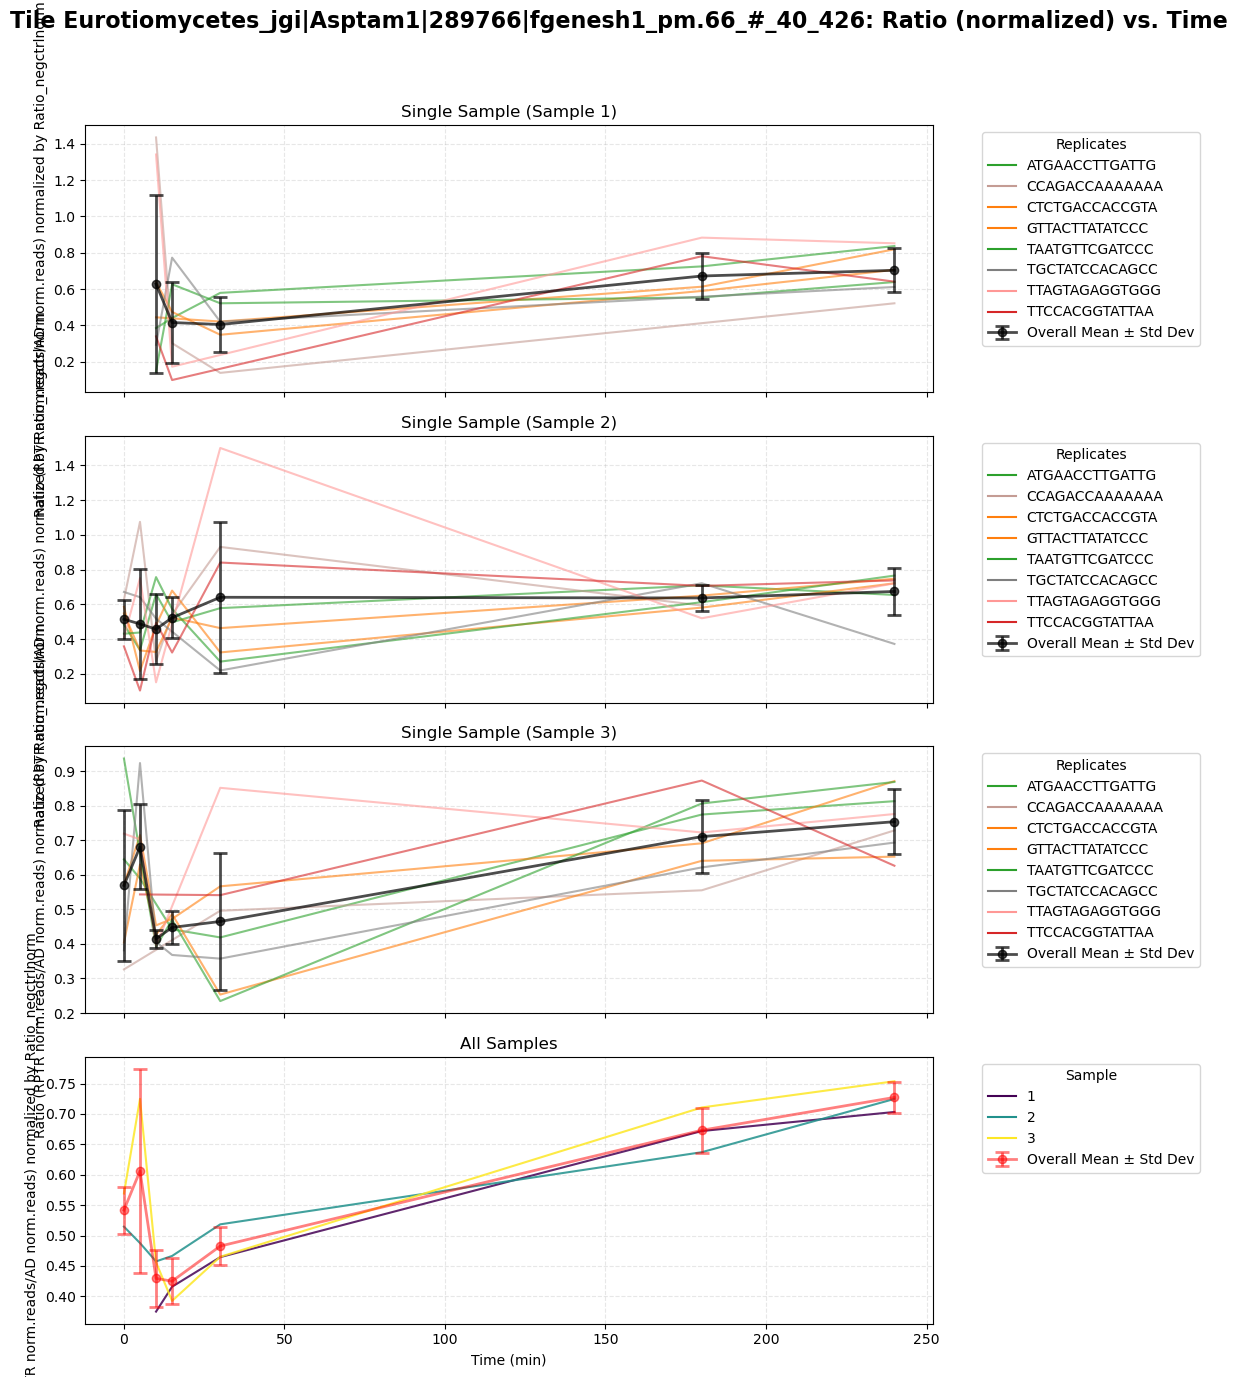

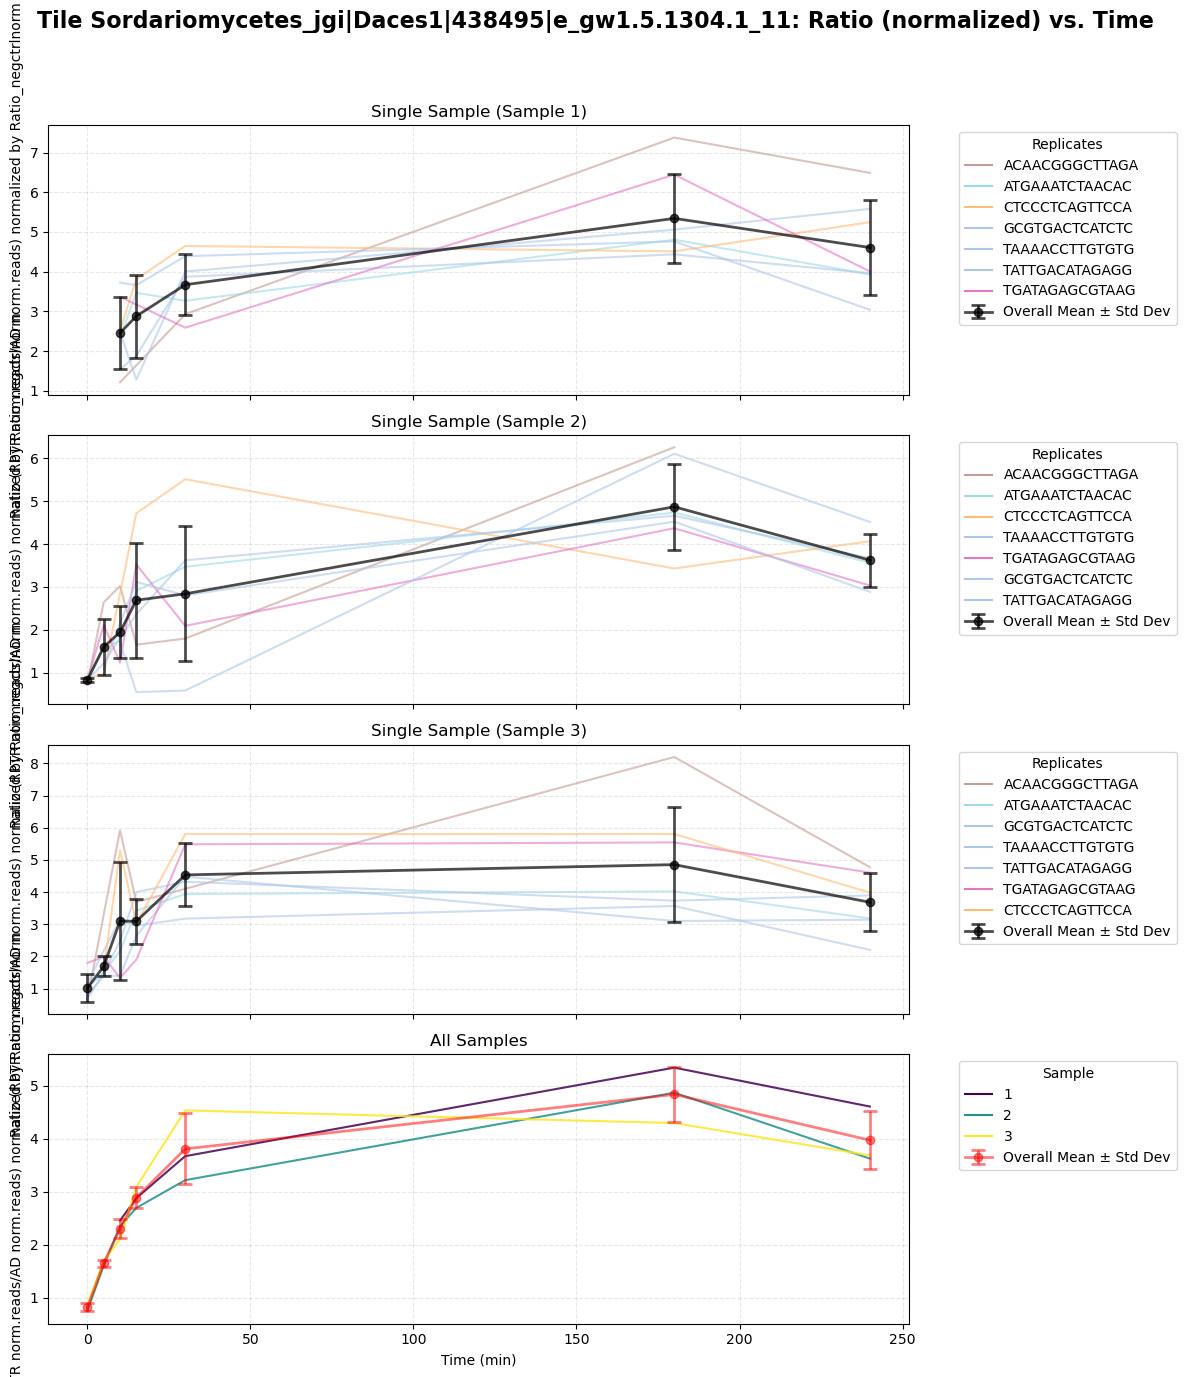

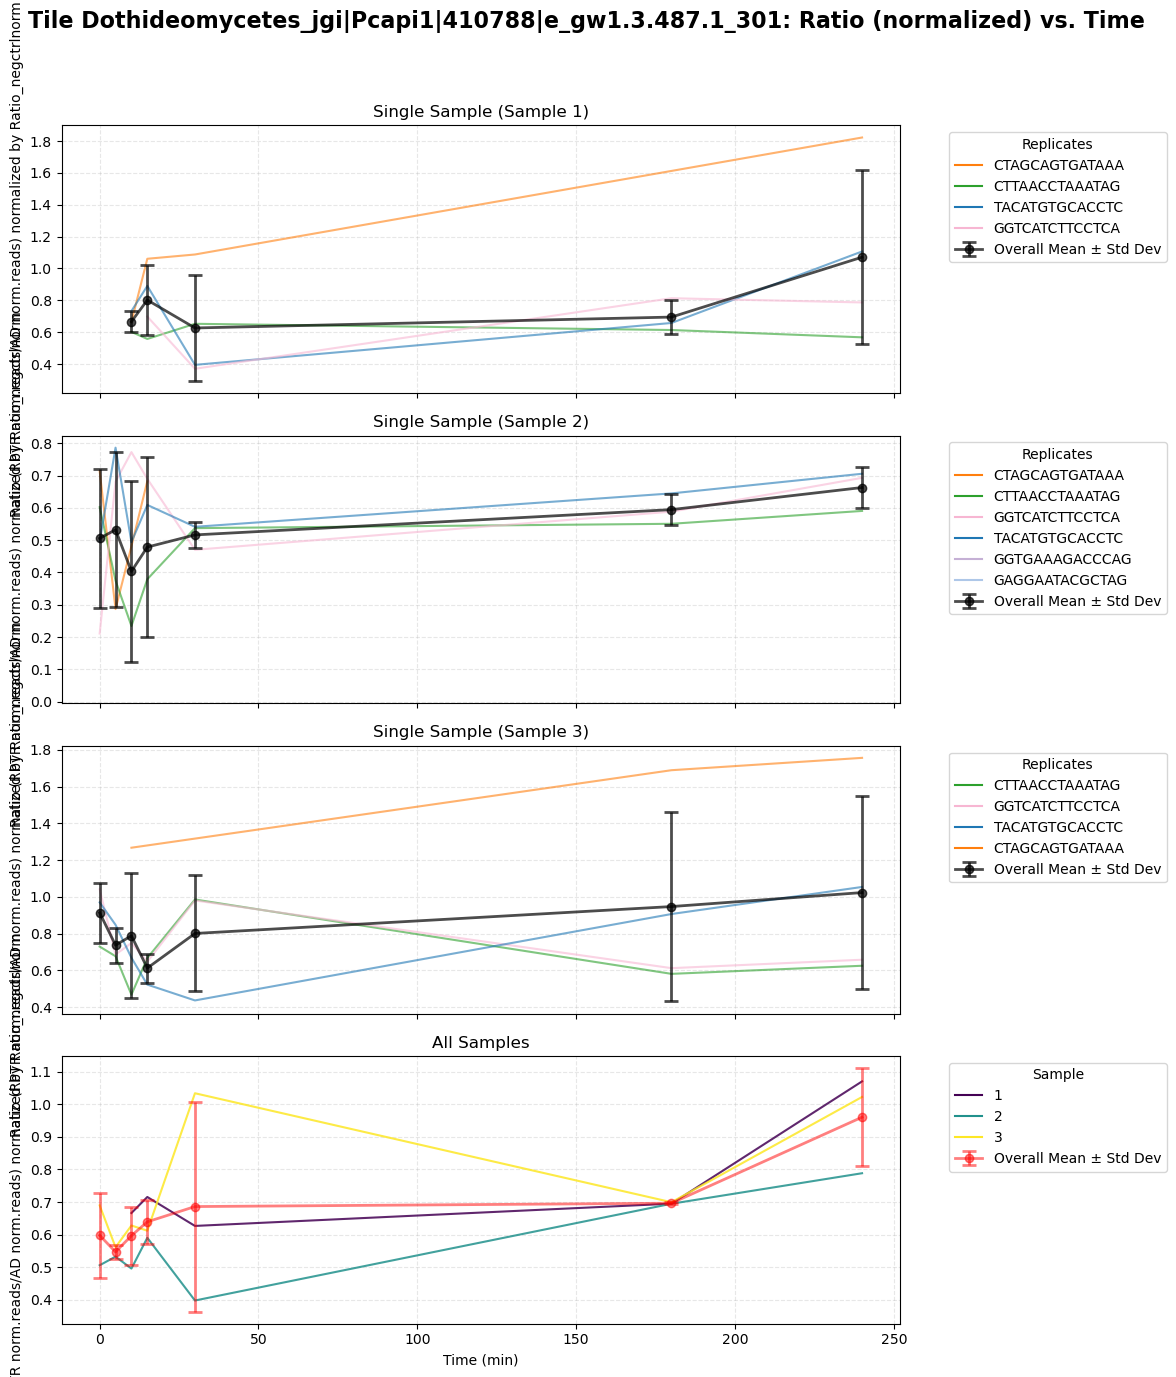

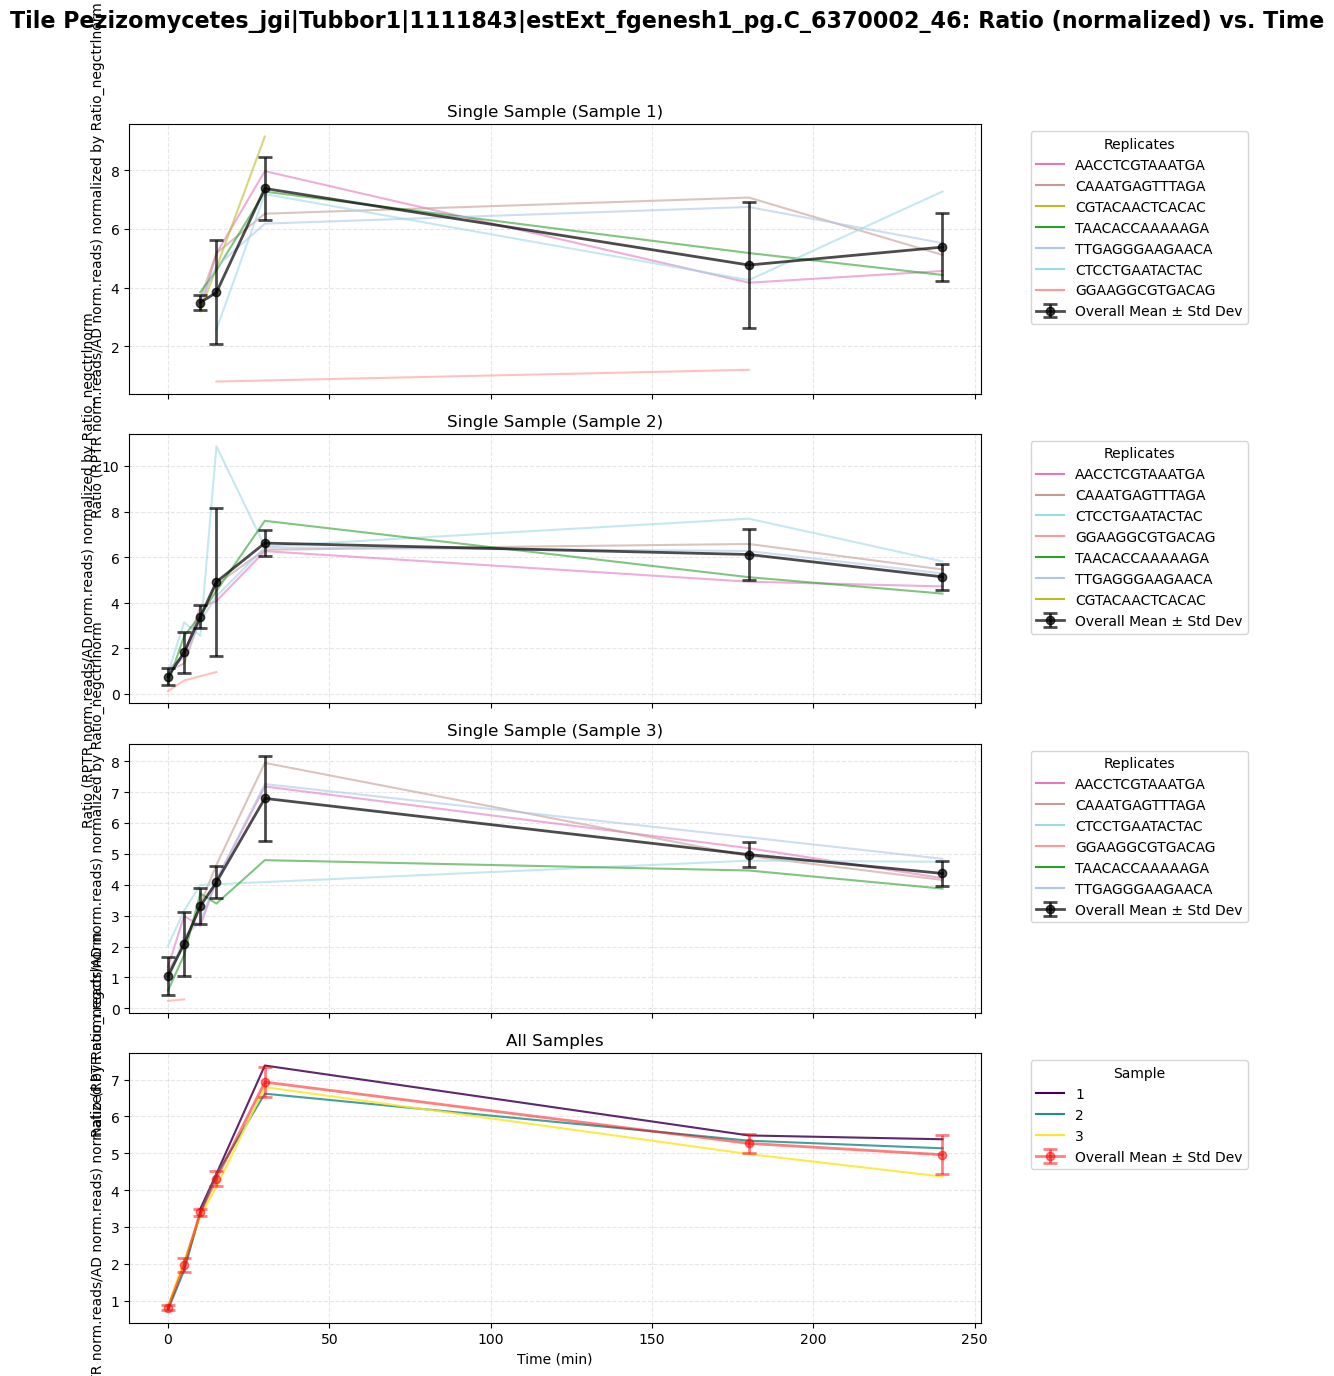

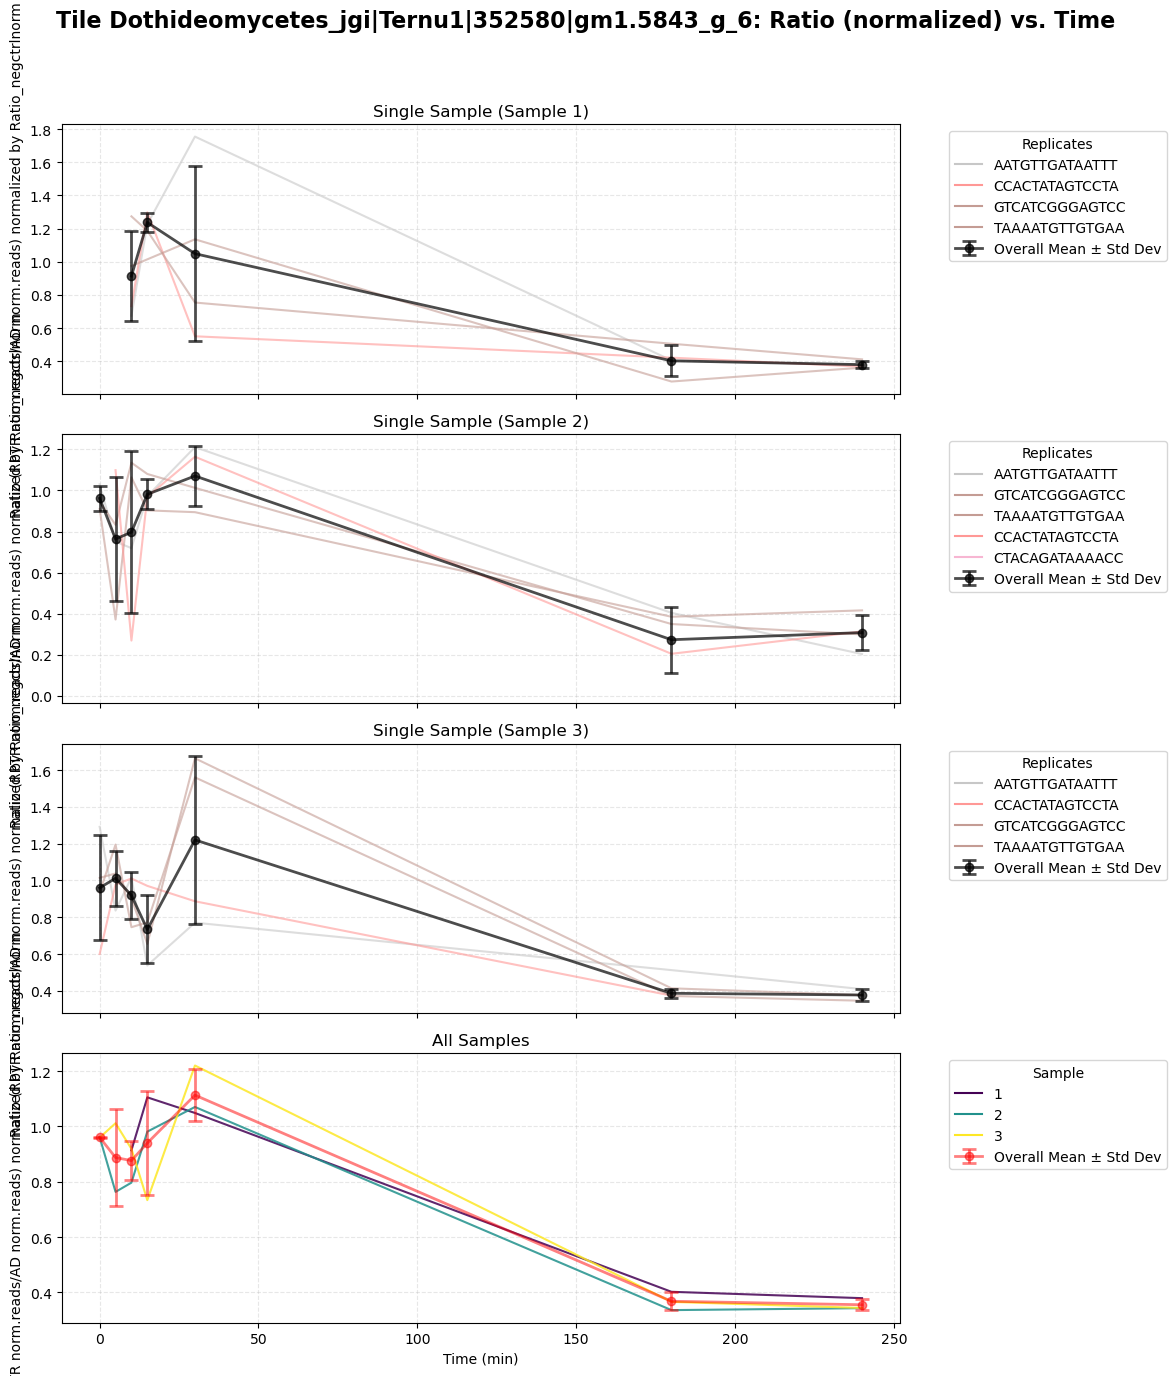

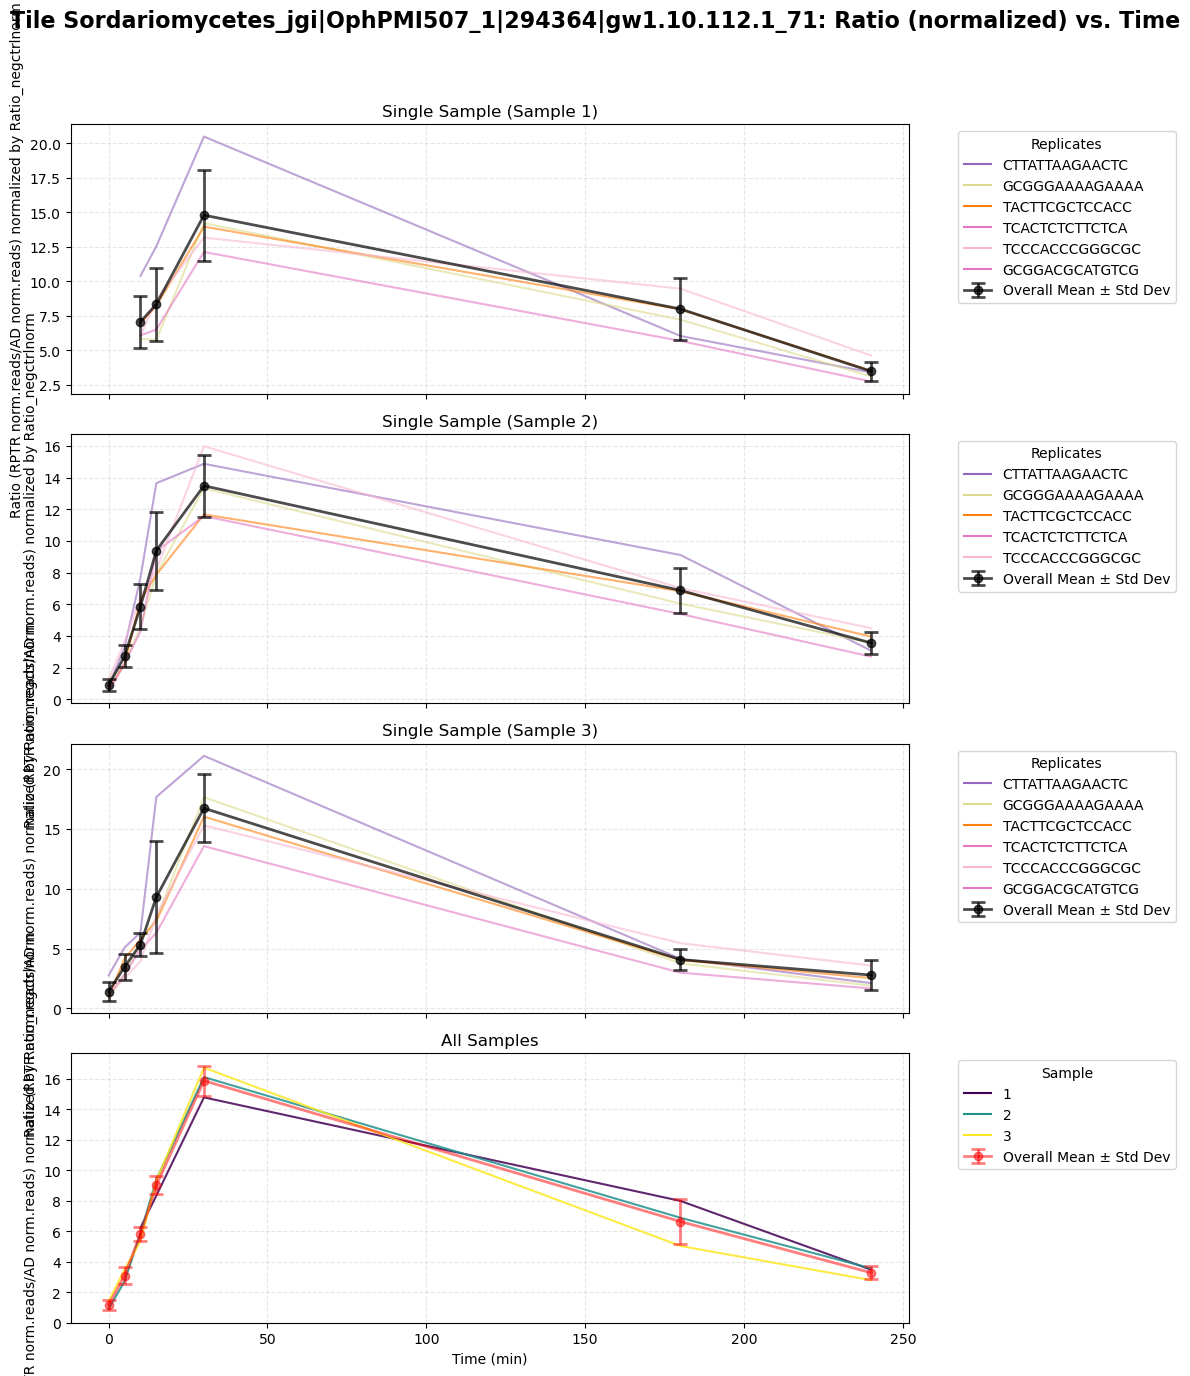

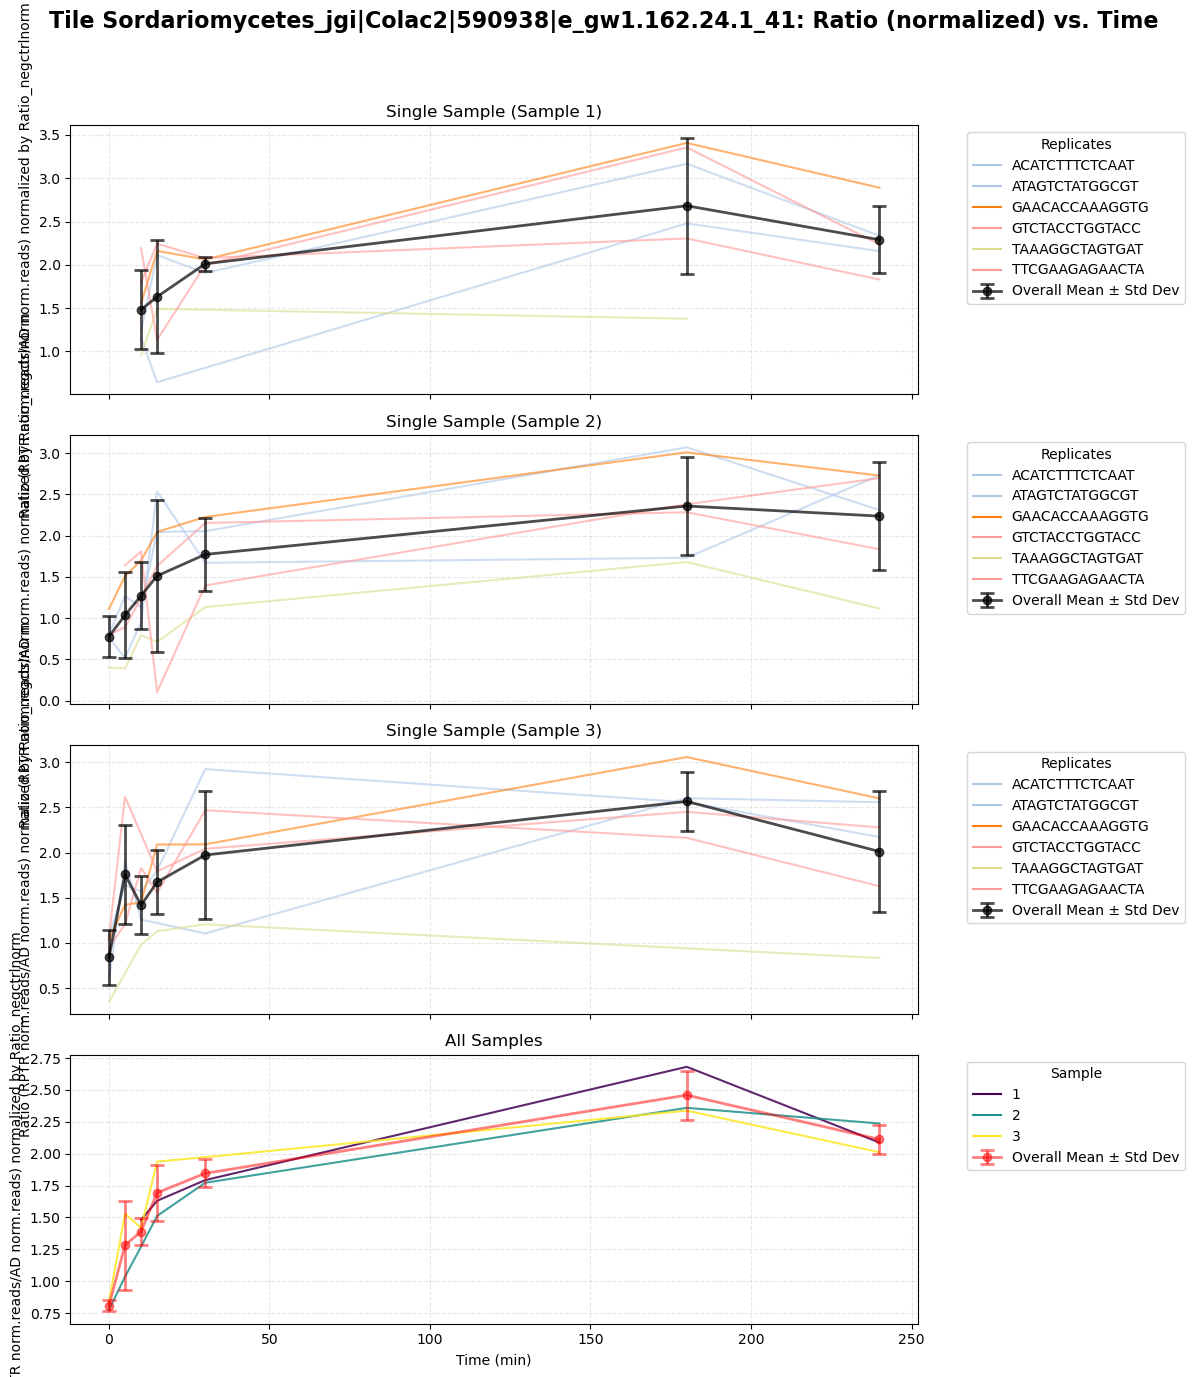

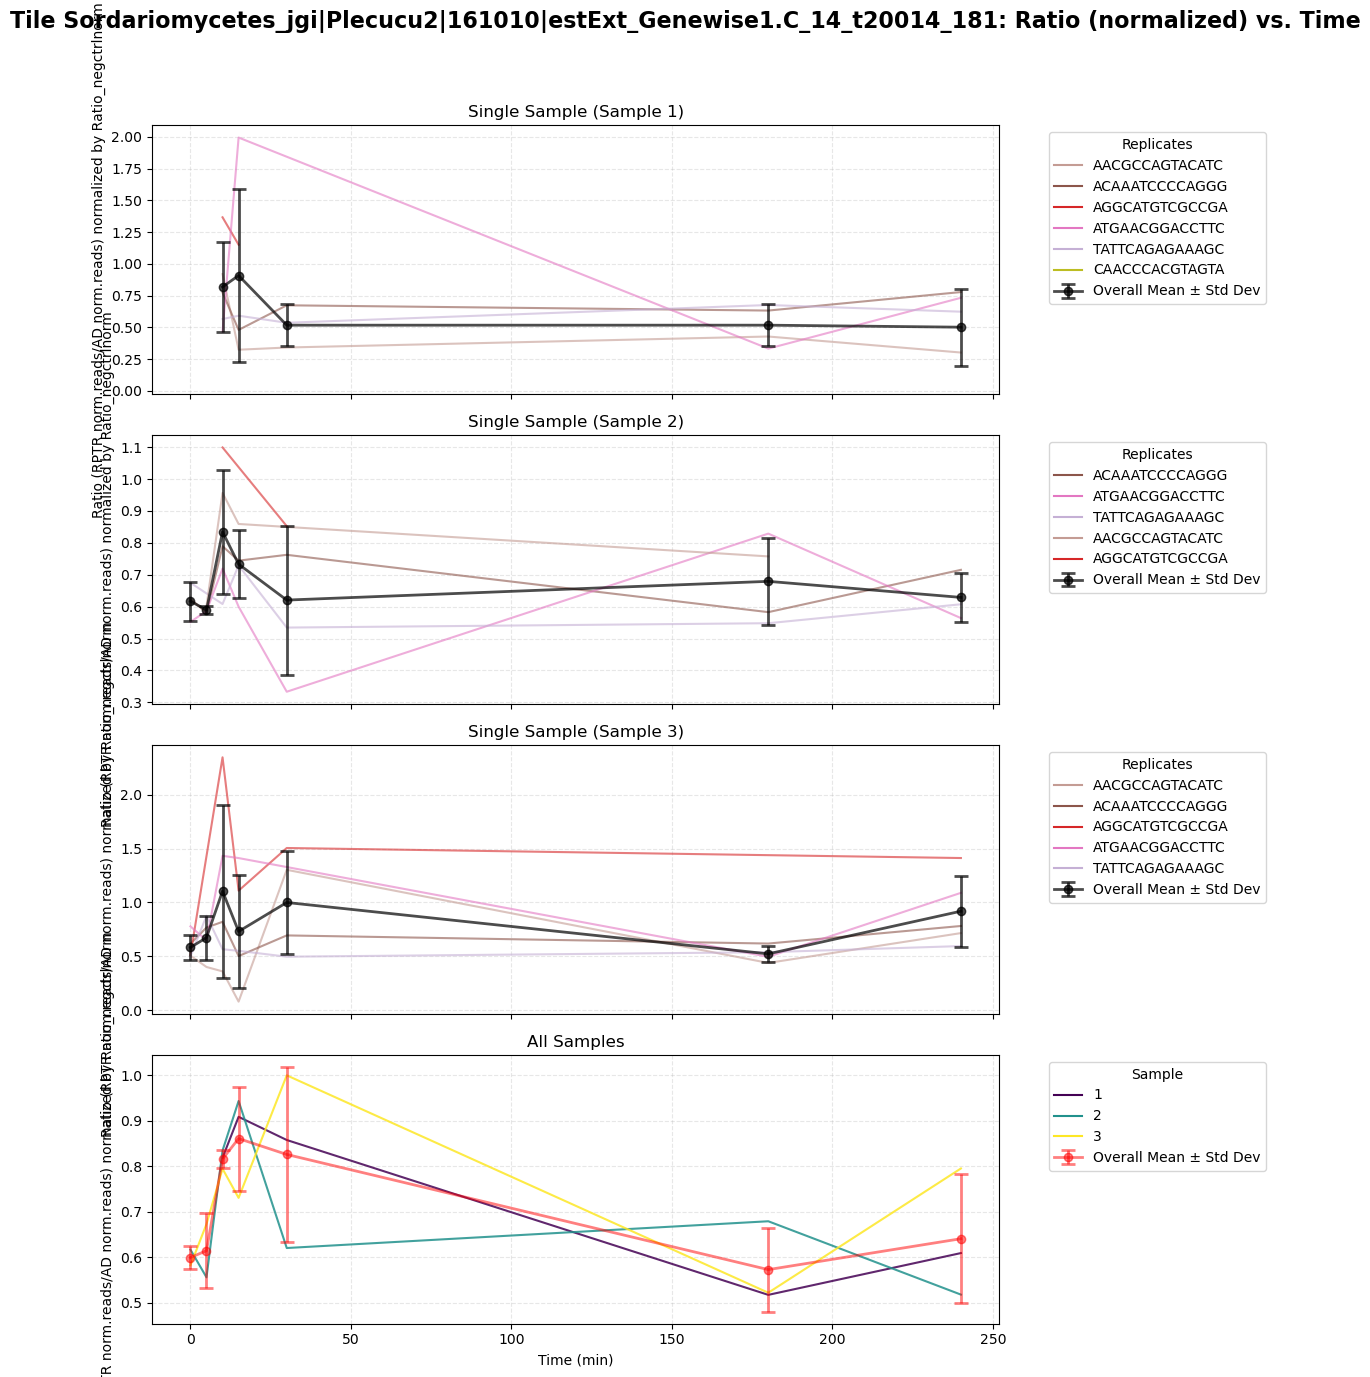

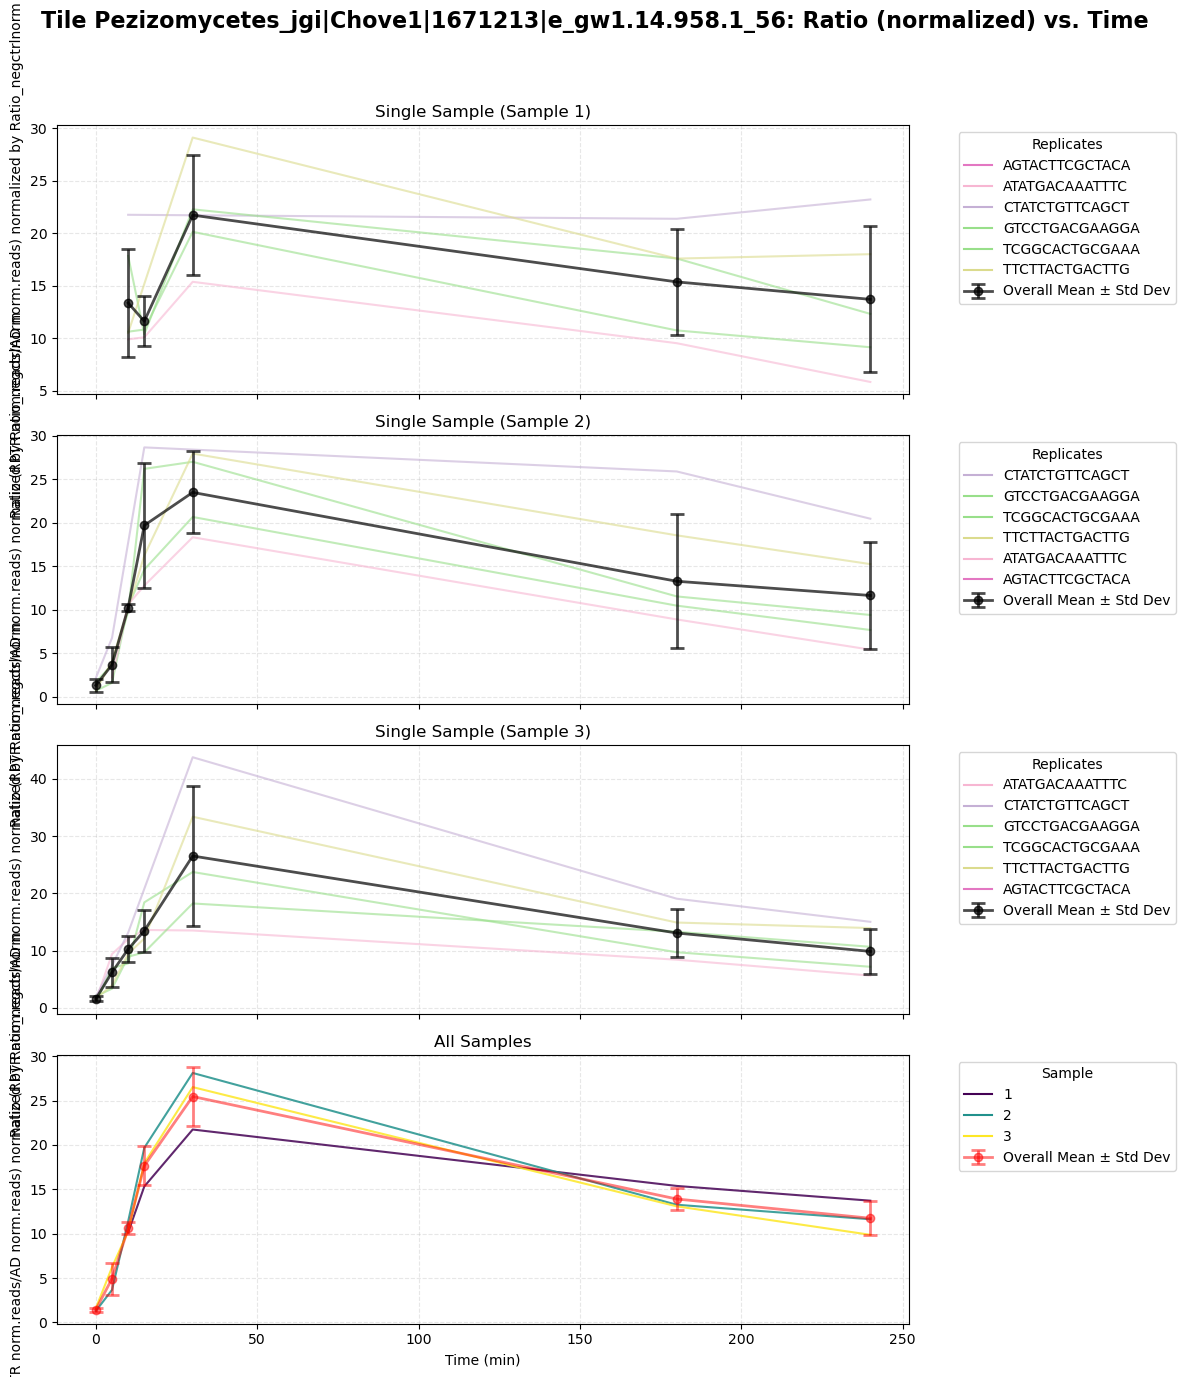

In [17]:
# Step 1: Find the top 10 tiles with the most unique rptr barcodes
top_tiles_intersect = intersectiondf.groupby('Tile')['RPTR_BC'].nunique().reset_index()
top_tiles_sorted_intersect = top_tiles_intersect.sort_values('RPTR_BC', ascending=False)
top_10_tiles_intersect = top_tiles_sorted_intersect.head(10)['Tile']

mean_dict1 = {}
for t in top_10_tiles_intersect.to_list():
    name, mean = tile_and_replicate_hillfxn(t, 'Ratio_negctrlnorm')
    mean_dict1[name] = mean 

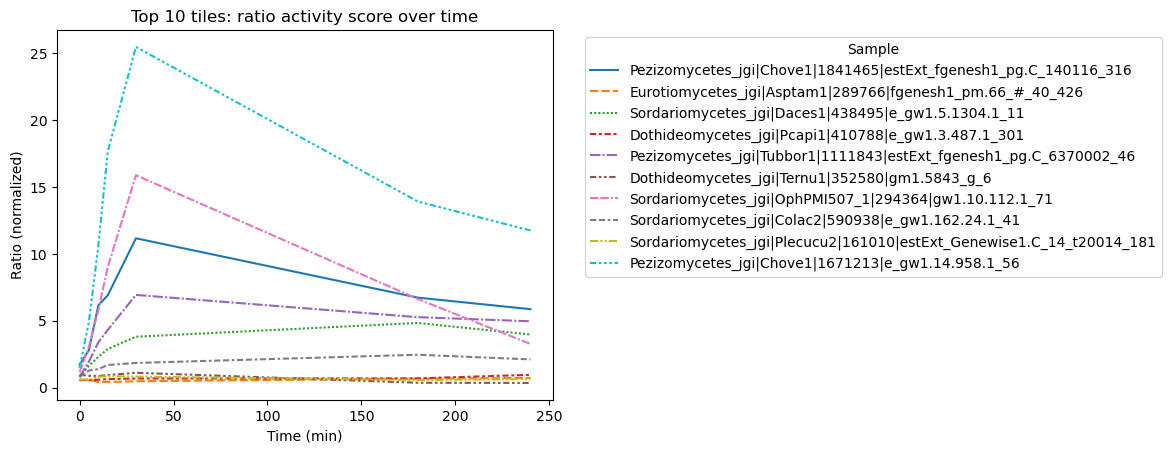

In [18]:
# for key, value in ctrl_mean_dict.items():
name_list1 = list(mean_dict1.keys())
mean_list1 = list(mean_dict1.values())
times_series= pd.Series([0,5,10,15,30, 180, 240])
df1 = pd.concat(mean_list1, axis=1,keys= name_list1)
df1 = df1.set_index(times_series)
# df.head()
sns.lineplot(data=df1)
plt.legend(title='Sample', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('Ratio (normalized)')
plt.xlabel('Time (min)')
plt.title('Top 10 tiles: ratio activity score over time')
# plt.savefig('vp16norm_figs/top10.jpg', bbox_inches='tight')
plt.show()

In [9]:
# Check the controls
intersectiondf_ctrl = intersectiondf.copy(deep=True)
intersectiondf_ctrl = intersectiondf_ctrl[intersectiondf_ctrl['is_control']!='experimental']
intersectiondf_ctrl

,RPTR_BC,RPTR_UMIs,RPTR_Reads,AD_BC,Tile,AD_UMIs,AD_Reads,Ratio,Ratio_negctrlnorm,Library,Time,sample,Name,is_control
25,TCCTCTACGGCTTG,54,5679.0,CCCTGCCGGTC,CCACCAACTGATGTTTCTTTGGGTGATGAATTGCATTTGGATGGTG...,417,4721.0,0.129496,0.614638,2_0,0,2,VP16N_F442A_0,low
148,CTACCACCCGCTAT,30,4213.0,ACCTCCCTGTG,TCTACTGATTCTACTCCAATGTTTGAATATCAGAATTTGGAGAATA...,241,3075.0,0.124481,0.590834,2_0,0,2,Gnc4Lib_Charge_HIGH_0,mid
157,TACGATCCAGTGAC,62,5104.0,CAAATTTCCAC,GATTCTCCAGGTCCAGGTGCTACTCCACATGATTCTGCTCCATATG...,516,6620.0,0.120155,0.570300,2_0,0,2,VP16C_F2A_0,low
206,TAGTCTAGAAGCCG,28,1815.0,CTTTGGTTCGA,CCACCAACTGATGTTTCTTTGGGTGATGAATTGCATTTGGATGGTG...,133,1621.0,0.210526,0.999236,2_0,0,2,VP16N_F442A_0,low
389,ACGATTCAGGTGAT,114,11877.0,ACTTAAGGTAG,ACTGACTTTATTGATGAAGAAGTTATTATGTCTATTGTTATTGAAA...,256,3076.0,0.445312,2.113618,2_0,0,2,CITED2_L2I_0,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314378,TCATCTAGTTCCCA,912,16213.0,GCGCCGCGGTC,CCACCAACTGATGTTTCTTTGGGTGATGAATTGCATTTGGATGGTG...,346,4331.0,2.635838,3.556113,3_240,240,3,VP16N_F442A_0,low
314637,GAACTAGAAGTAAC,45,705.0,GGCTCGCAAAC,TCTACTGATTCTACTCCAATGTTTGAATATGAGAATTTGCAGAATA...,18,183.0,2.500000,3.372848,3_240,240,3,Gnc4Lib_Charge_LOW_0,mid
314677,CAGGATCCGTATCA,8829,162893.0,GGAGACCGTCC,ATGACTGATTCTACTCCAATGTTTGAATATGAATTGACTGAGAATA...,925,10811.0,9.544865,12.877352,3_240,240,3,Gnc4Lib_Disorder_HIGH_0,high
314792,ATTGTCCTCCGTCA,1482,27368.0,CCCTAGCCGGT,GATTCTCCAGGTCCAGGTGCTACTCCACATGATTCTGCTCCATATG...,778,9457.0,1.904884,2.569954,3_240,240,3,VP16C_F2A_0,low


In [10]:
# Step 1: Find the top 10 tiles with the most unique rptr barcodes
top_tiles_intersect = intersectiondf_ctrl.groupby('Tile')['RPTR_BC'].nunique().reset_index()
top_tiles_sorted_intersect = top_tiles_intersect.sort_values('RPTR_BC', ascending=False)
top_10_tiles_intersect = top_tiles_sorted_intersect.head(10)['Tile']
for t in top_10_tiles_intersect.to_list():
    print(t)
    print(intersectiondf_ctrl[intersectiondf_ctrl['Tile']==t].iloc[0,12])
    tile_and_replicate_hillfxn(t) #ran this as save_fig=true 1/21/25

TTGACTGCTTTGACTTCTCCATCTTTGTTTGATGGTTCTCCAGACTTTGATACATTTGATATTTCTCCAAACTTTGGTCATTCTGATTTGGAGAATCCAGATACTTGGTTCTCTTTGTTT
Gnc4Lib_ChopOrthologs_HIGH_0


TypeError: tile_and_replicate_hillfxn() missing 1 required positional argument: 'scoretype'

# Make the T1/2 & Vmax dataframe

In [19]:
def remove_outliers_fast(df, group_cols, value_col):
    """Remove outliers based on IQR efficiently without using apply"""
    # Compute Q1 and Q3 per group
    q1 = df.groupby(group_cols)[value_col].transform(lambda x: x.quantile(0.25))
    q3 = df.groupby(group_cols)[value_col].transform(lambda x: x.quantile(0.75))
    iqr = q3 - q1

    # Define outlier bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Apply filtering in a vectorized manner
    return df[(df[value_col] >= lower_bound) & (df[value_col] <= upper_bound)]

In [25]:
# Count occurrences of each (Tile, Time, Sample) combination
tile_time_sample_counts = concatenated_df.groupby('Tile')['sample'].nunique()
# Identify tiles that appear in all time points and samples
valid_tiles = tile_time_sample_counts[tile_time_sample_counts>1].index
# Filter concatenated_df to only keep valid Tiles
filtered_cat_1 = concatenated_df[concatenated_df['Tile'].isin(valid_tiles)]
# Optional: Check how many tiles were removed
print(f"Original Tiles: {concatenated_df['Tile'].nunique()}, Filtered Tiles: {filtered_cat_1['Tile'].nunique()}")

# Remove outliers within each sample
filtered_cat_2 = remove_outliers_fast(filtered_cat_1, ['sample', 'Tile', 'Time'], 'Ratio_negctrlnorm')
print(f"Outlier Filtered Tiles: {filtered_cat_2['Tile'].nunique()}")

# Compute sample-level means
sample_means_cat = filtered_cat_2.groupby(['Tile', 'Time', 'sample'])['Ratio_negctrlnorm'].mean().reset_index()

# Compute the mean across samples (not just raw mean)
final_means_cat = sample_means_cat.groupby(['Tile', 'Time'])['Ratio_negctrlnorm'].mean().unstack(level='Time')

# Compute standard deviation across sample means
std_devs_cat = sample_means_cat.groupby(['Tile', 'Time'])['Ratio_negctrlnorm'].std().unstack(level='Time')

final_means_cat['Vmax'] = final_means_cat.max(axis=1)
final_means_cat['Avg_StdDev'] = std_devs_cat.mean(axis=1)

# Display the result
final_means_cat


Original Tiles: 11488, Filtered Tiles: 11333
Outlier Filtered Tiles: 11333


Time,0,5,10,15,30,180,240,Vmax,Avg_StdDev
Tile,,,,,,,,,
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGATCCAGTTGCTTTGAAGAGAGCTAGAAATACTGAAGCTGCTAGAAGATCTAGAGCTAGGAAATTGGAAAGAATG,1.090271,1.047174,1.062693,1.532920,1.787659,1.240728,1.206545,1.787659,0.372246
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAAAGATGCTGCTGCTTTGAAGAGAGCTAAGAATACTGAAGCTGCTAGAAGATCTAGAGCTAGGAAGATGGAAAGA,1.209351,1.683877,1.819540,1.700459,1.885667,2.317024,2.080985,2.317024,0.286557
AAACAAATGTATATTGGTTCTAATAAACCATTGGGTAAAGATCATAGAGGTTATAATGCTCATAATTGGAAACAATGTGCTATTTACTTTCATATTAGATATCCAAATGTTTCTAATTGT,1.233342,1.985744,1.000460,0.730895,0.797948,0.709995,0.732983,1.985744,0.256619
AAACAACCAGATGTTGCTACTTGGGATGCTCATTCTAATAAAGGTCAATGTTTGTTAAATTCTGGTGGTTCTGCTAGACCATTGATTATTTGGTTGCCACATTCTCACTTTAAAGAATAT,2.538508,0.937011,1.299895,1.467031,1.947597,1.668606,1.693269,2.538508,1.076864
AAACAAGATAAAGATGATGTTACTTCTGAAGTTGCTGATAGAAGATGTAAATCTACTTCTGATTCTCAAGATGTTTATGATAAACCAGGTGAATCTGAATCTCCAGAAAGAACTGAATAT,0.596515,0.934732,1.127691,1.071415,1.427080,1.504457,1.322705,1.504457,0.411975
...,...,...,...,...,...,...,...,...,...
TTTGTTGATGGTTTGGATGCTGCTTCTTTGGCTATGTTTGATACTCAACAATTGGATAAAGTTCAAGCATTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGCTCCA,1.105620,10.445686,18.108378,25.314241,38.055564,15.885584,11.023455,38.055564,2.425184
TTTGTTGCTTCTCCAACATTTAATCATAAATTCTCTTCTTCTAATGCATTTACTACTGAACAAATGAAGACATTTGATCCAGAAGCTGCATTTAATGAATTGTTCTCTCCAGAGTTCTCT,1.263978,10.294880,30.615512,26.635877,73.708402,24.434864,17.924639,73.708402,5.002071
TTTGTTGGTGATGGTGATTTGGATCAATCTTTGGCTGCTGATCCATGGTATCCATTGTTTCCAGAATCTGATAAATTGGATCAACCAACTAAAGTTGAACAATCTCCATTGATTATTGAT,1.803973,6.915342,14.324264,20.019784,42.340589,19.689651,12.861237,42.340589,3.081669


In [26]:
final_means_cat.to_csv('timeseries_UMIs_20250415.csv')

# Next

In [10]:
final_means_cat = pd.read_csv('timeseries_UMIs_20250415.csv', index_col=0)
final_means_cat.columns = [int(col) if col.isdigit() else col for col in final_means_cat.columns]

final_means_cat.head()

,0,5,10,15,30,180,240,Vmax,Avg_StdDev
Tile,,,,,,,,,
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGATCCAGTTGCTTTGAAGAGAGCTAGAAATACTGAAGCTGCTAGAAGATCTAGAGCTAGGAAATTGGAAAGAATG,1.090271,1.047174,1.062693,1.532920,1.787659,1.240728,1.206545,1.787659,0.372246
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAAAGATGCTGCTGCTTTGAAGAGAGCTAAGAATACTGAAGCTGCTAGAAGATCTAGAGCTAGGAAGATGGAAAGA,1.209351,1.683877,1.819540,1.700459,1.885667,2.317024,2.080985,2.317024,0.286557
AAACAAATGTATATTGGTTCTAATAAACCATTGGGTAAAGATCATAGAGGTTATAATGCTCATAATTGGAAACAATGTGCTATTTACTTTCATATTAGATATCCAAATGTTTCTAATTGT,1.233342,1.985744,1.000460,0.730895,0.797948,0.709995,0.732983,1.985744,0.256619
AAACAACCAGATGTTGCTACTTGGGATGCTCATTCTAATAAAGGTCAATGTTTGTTAAATTCTGGTGGTTCTGCTAGACCATTGATTATTTGGTTGCCACATTCTCACTTTAAAGAATAT,2.538508,0.937011,1.299895,1.467031,1.947597,1.668606,1.693269,2.538508,1.076864
AAACAAGATAAAGATGATGTTACTTCTGAAGTTGCTGATAGAAGATGTAAATCTACTTCTGATTCTCAAGATGTTTATGATAAACCAGGTGAATCTGAATCTCCAGAAAGAACTGAATAT,0.596515,0.934732,1.127691,1.071415,1.427080,1.504457,1.322705,1.504457,0.411975


In [4]:
def identify_decreasing_tiles(df):
    """Identify tiles that decrease from the start and separate them."""
    decreasing_tiles = df[(df.iloc[:,:7].diff(axis=1) <= 0).all(axis=1)]
    print(f' Number of decreasing tiles {len(decreasing_tiles)}')
    increasing_tiles = df.drop(decreasing_tiles.index)
    return increasing_tiles, decreasing_tiles

def extract_increasing_phase(df):
    """Extract the increasing phase for each tile up to its max activity."""
    increasing_dfs = {}
    counter = 0
    for tile, row in df.iterrows():
        max_time_idx = row.astype(float).idxmax()
        increasing_dfs[tile] = row.loc[:max_time_idx]
        counter+=1
    print(f'Increasing dfs:{len(increasing_dfs)}')
    print(f'Total dfs:{counter}')
    return increasing_dfs

def estimate_t_half(time, activity):
    """Estimate T1/2 using linear interpolation between surrounding points."""
    # print(activity[0])
    half_max = ((max(activity)-activity[0]) / 2) + activity[0]
    
    # Find two time points where half_max falls between
    for i in range(len(activity) - 1):
        if activity[i] <= half_max <= activity[i + 1]:
            t1, t2 = time[i], time[i + 1]
            a1, a2 = activity[i], activity[i + 1]
            
            # Linear regression on these two points
            model = LinearRegression()
            model.fit(np.array([t1, t2]).reshape(-1, 1), np.array([a1, a2]))
            t_half = (half_max - model.intercept_) / model.coef_[0]
            return t_half
    
    return np.nan  # Return NaN if no valid points found

def analyze_tiles_lin(df):
    increasing_df, decreasing_df = identify_decreasing_tiles(df)
    increasing_phases = extract_increasing_phase(increasing_df)
    results = []
    
    for tile, data in increasing_phases.items():
        time = data.index.astype(float)
        activity = data.values
        
        t_half = estimate_t_half(time, activity)
        results.append([tile, t_half])
    
    columns = ["Tile", "T1/2"]
    return pd.DataFrame(results, columns=columns).set_index("Tile"), decreasing_df

def filter_by_maximum_threshold(df, threshold=5):
    """Keep tiles where max value is at least `threshold` units higher than value at time 0."""
    return df[(df.iloc[:,:7].max(axis=1) - df.iloc[:, 0]) >= threshold]


In [13]:
inc_all, dec_all = analyze_tiles_lin(final_means_cat.dropna())
inc_all

 Number of decreasing tiles 0
Increasing dfs:10874
Total dfs:10874


,T1/2
Tile,
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGATCCAGTTGCTTTGAAGAGAGCTAGAAATACTGAAGCTGCTAGAAGATCTAGAGCTAGGAAATTGGAAAGAATG,14.000960
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAAAGATGCTGCTGCTTTGAAGAGAGCTAAGAATACTGAAGCTGCTAGAAGATCTAGAGCTAGGAAGATGGAAAGA,7.923072
AAACAAATGTATATTGGTTCTAATAAACCATTGGGTAAAGATCATAGAGGTTATAATGCTCATAATTGGAAACAATGTGCTATTTACTTTCATATTAGATATCCAAATGTTTCTAATTGT,2.500000
AAACAACCAGATGTTGCTACTTGGGATGCTCATTCTAATAAAGGTCAATGTTTGTTAAATTCTGGTGGTTCTGCTAGACCATTGATTATTTGGTTGCCACATTCTCACTTTAAAGAATAT,NaN
AAACAAGATAAAGATGATGTTACTTCTGAAGTTGCTGATAGAAGATGTAAATCTACTTCTGATTCTCAAGATGTTTATGATAAACCAGGTGAATCTGAATCTCCAGAAAGAACTGAATAT,7.999446
...,...
TTTGTTGATGGTTTGGATGCTGCTTCTTTGGCTATGTTTGATACTCAACAATTGGATAAAGTTCAAGCATTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGCTCCA,11.021539
TTTGTTGCTTCTCCAACATTTAATCATAAATTCTCTTCTTCTAATGCATTTACTACTGAACAAATGAAGACATTTGATCCAGAAGCTGCATTTAATGAATTGTTCTCTCCAGAGTTCTCT,18.457531
TTTGTTGGTGATGGTGATTTGGATCAATCTTTGGCTGCTGATCCATGGTATCCATTGTTTCCAGAATCTGATAAATTGGATCAACCAACTAAAGTTGAACAATCTCCATTGATTATTGAT,16.379316


In [14]:
filtered_final_means_cat = filter_by_maximum_threshold(final_means_cat).dropna()
filtered_final_means_cat

,0,5,10,15,30,180,240,Vmax,Avg_StdDev
Tile,,,,,,,,,
AAACAAGGTAATAAGATGTTCTCTGGTAATTATACTTCTTATCATTTGCCACCACCAAATATGAGATTGCAACCACATGCTGAATTGGATTTGTTGGACTTTGCTACATTTGATGGTGGT,0.851655,2.508576,5.794430,6.832395,12.941360,7.872477,4.974632,12.941360,0.858059
AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTGGTTTGCCATCTGGTACTGTTTCTCCAACTGATTTGATGTTGGATGCTTCTGCTCCATCTTCTGCTACATTTACT,2.347815,12.141733,21.738648,29.841027,54.876878,17.966665,13.429892,54.876878,3.056232
AAACAATTTCAGAATTATCAAAGAAGAAGATTGATGTCTCAATCTAATTTGATTCAAGGTTTGGAAATGTCTGACTTCTTTAATGATATTCCATCTCATCCATTTGGTAATGACTTTGAT,1.724267,4.148439,6.178987,9.341038,15.666855,11.904372,9.808035,15.666855,0.835043
AAACATGCTGATATGGATTTGTTTGATGAATTTACTGCATTTGAAGGTGGTGCTTCTACTACTCAGAATGCATTTCCATCTGCTTATTCTTCTCCAGCTGTTCCAACTATTTATGATCCA,0.716702,5.620911,8.889710,11.602415,29.655114,12.913788,8.601112,29.655114,2.982370
AAACCAGAAATTATTGGTGAATTGTCTTGTCATTTGCCAACTGCTGGTGCTCATGTTACTGGTGAACCAGATCATTCTCCAATTTCTGTTCATACTGATGTCTTGGATTCTGTCTTCTCT,0.971893,3.132003,5.638187,6.199079,6.350312,8.506463,6.853283,8.506463,1.251675
...,...,...,...,...,...,...,...,...,...
TTTGTTAAATCTTTGAAAGGTAGGAAACCATTGACTGGTGTTGCTTTGGGTATTTATTCTTATGAAGTTAGATCTAAGACTGATAATTCTTTGAATTTGAGAATCTTGACTTTGCATACT,0.839056,4.354328,8.822356,5.450700,35.162836,11.479959,9.325870,35.162836,8.128643
TTTGTTGATGGTTTGGATGCTGCTTCTTTGGCTATGTTTGATACTCAACAATTGGATAAAGTTCAAGCATTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGCTCCA,1.105620,10.445686,18.108378,25.314241,38.055564,15.885584,11.023455,38.055564,2.425184
TTTGTTGCTTCTCCAACATTTAATCATAAATTCTCTTCTTCTAATGCATTTACTACTGAACAAATGAAGACATTTGATCCAGAAGCTGCATTTAATGAATTGTTCTCTCCAGAGTTCTCT,1.263978,10.294880,30.615512,26.635877,73.708402,24.434864,17.924639,73.708402,5.002071


In [15]:
non_decreasers = filtered_final_means_cat.copy(deep=True)
non_decreasers = non_decreasers.reset_index()
non_decreasers = non_decreasers.merge(inc_all.reset_index(), on='Tile', how='inner') # should be the same bc there were no continuous decreasers
non_decreasers = non_decreasers.set_index('Tile')
non_decreasers

,0,5,10,15,30,180,240,Vmax,Avg_StdDev,T1/2
Tile,,,,,,,,,,
AAACAAGGTAATAAGATGTTCTCTGGTAATTATACTTCTTATCATTTGCCACCACCAAATATGAGATTGCAACCACATGCTGAATTGGATTTGTTGGACTTTGCTACATTTGATGGTGGT,0.851655,2.508576,5.794430,6.832395,12.941360,7.872477,4.974632,12.941360,0.858059,15.157422
AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTGGTTTGCCATCTGGTACTGTTTCTCCAACTGATTTGATGTTGGATGCTTCTGCTCCATCTTCTGCTACATTTACT,2.347815,12.141733,21.738648,29.841027,54.876878,17.966665,13.429892,54.876878,3.056232,14.241778
AAACAATTTCAGAATTATCAAAGAAGAAGATTGATGTCTCAATCTAATTTGATTCAAGGTTTGGAAATGTCTGACTTCTTTAATGATATTCCATCTCATCCATTTGGTAATGACTTTGAT,1.724267,4.148439,6.178987,9.341038,15.666855,11.904372,9.808035,15.666855,0.835043,13.979339
AAACATGCTGATATGGATTTGTTTGATGAATTTACTGCATTTGAAGGTGGTGCTTCTACTACTCAGAATGCATTTCCATCTGCTTATTCTTCTCCAGCTGTTCCAACTATTTATGATCCA,0.716702,5.620911,8.889710,11.602415,29.655114,12.913788,8.601112,29.655114,2.982370,17.977527
AAACCAGAAATTATTGGTGAATTGTCTTGTCATTTGCCAACTGCTGGTGCTCATGTTACTGGTGAACCAGATCATTCTCCAATTTCTGTTCATACTGATGTCTTGGATTCTGTCTTCTCT,0.971893,3.132003,5.638187,6.199079,6.350312,8.506463,6.853283,8.506463,1.251675,8.206420
...,...,...,...,...,...,...,...,...,...,...
TTTGTTAAATCTTTGAAAGGTAGGAAACCATTGACTGGTGTTGCTTTGGGTATTTATTCTTATGAAGTTAGATCTAAGACTGATAATTCTTTGAATTTGAGAATCTTGACTTTGCATACT,0.839056,4.354328,8.822356,5.450700,35.162836,11.479959,9.325870,35.162836,8.128643,21.335919
TTTGTTGATGGTTTGGATGCTGCTTCTTTGGCTATGTTTGATACTCAACAATTGGATAAAGTTCAAGCATTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTGCTCCA,1.105620,10.445686,18.108378,25.314241,38.055564,15.885584,11.023455,38.055564,2.425184,11.021539
TTTGTTGCTTCTCCAACATTTAATCATAAATTCTCTTCTTCTAATGCATTTACTACTGAACAAATGAAGACATTTGATCCAGAAGCTGCATTTAATGAATTGTTCTCTCCAGAGTTCTCT,1.263978,10.294880,30.615512,26.635877,73.708402,24.434864,17.924639,73.708402,5.002071,18.457531


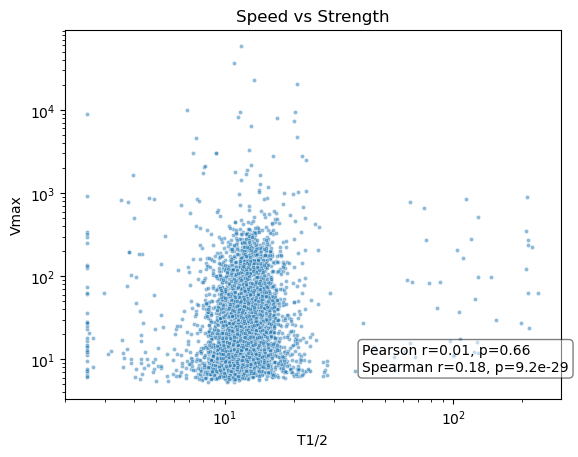

In [37]:



# Combine the relevant columns and drop rows with NaN or inf
valid_data = non_decreasers[['Vmax', 'T1/2']].replace([np.inf, -np.inf], np.nan).dropna()

# Extract cleaned x and y
y = valid_data['Vmax']
x = valid_data['T1/2']

# Compute correlations
pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

# Plot
sns.scatterplot(data=valid_data, y='Vmax', x='T1/2', 
                marker='.', alpha=0.5)
plt.xscale('log')
plt.yscale('log')

# Annotate
plt.text(
    0.6, 0.15,
    f"Pearson r={pearson_r:.2f}, p={pearson_p:.2g}\nSpearman r={spearman_r:.2f}, p={spearman_p:.2g}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
)

plt.title("Speed vs Strength")

plt.show()


<Axes: ylabel='Count'>

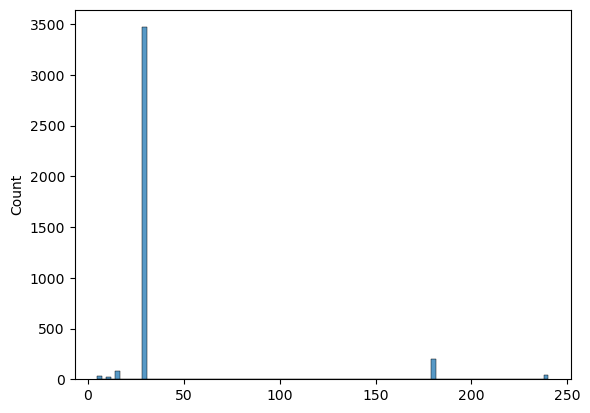

In [20]:
sns.histplot(non_decreasers.iloc[:,:7].idxmax(axis=1), bins=100)
# plt.xlim(0,40)

In [21]:
non_decreasers['Peak_minutes'] = non_decreasers.iloc[:,:7].idxmax(axis=1)
non_decreasers.head()

,0,5,10,15,30,180,240,Vmax,Avg_StdDev,T1/2,Peak_minutes
Tile,,,,,,,,,,,
AAACAAGGTAATAAGATGTTCTCTGGTAATTATACTTCTTATCATTTGCCACCACCAAATATGAGATTGCAACCACATGCTGAATTGGATTTGTTGGACTTTGCTACATTTGATGGTGGT,0.851655,2.508576,5.794430,6.832395,12.941360,7.872477,4.974632,12.941360,0.858059,15.157422,30
AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTGGTTTGCCATCTGGTACTGTTTCTCCAACTGATTTGATGTTGGATGCTTCTGCTCCATCTTCTGCTACATTTACT,2.347815,12.141733,21.738648,29.841027,54.876878,17.966665,13.429892,54.876878,3.056232,14.241778,30
AAACAATTTCAGAATTATCAAAGAAGAAGATTGATGTCTCAATCTAATTTGATTCAAGGTTTGGAAATGTCTGACTTCTTTAATGATATTCCATCTCATCCATTTGGTAATGACTTTGAT,1.724267,4.148439,6.178987,9.341038,15.666855,11.904372,9.808035,15.666855,0.835043,13.979339,30
AAACATGCTGATATGGATTTGTTTGATGAATTTACTGCATTTGAAGGTGGTGCTTCTACTACTCAGAATGCATTTCCATCTGCTTATTCTTCTCCAGCTGTTCCAACTATTTATGATCCA,0.716702,5.620911,8.889710,11.602415,29.655114,12.913788,8.601112,29.655114,2.982370,17.977527,30
AAACCAGAAATTATTGGTGAATTGTCTTGTCATTTGCCAACTGCTGGTGCTCATGTTACTGGTGAACCAGATCATTCTCCAATTTCTGTTCATACTGATGTCTTGGATTCTGTCTTCTCT,0.971893,3.132003,5.638187,6.199079,6.350312,8.506463,6.853283,8.506463,1.251675,8.206420,180


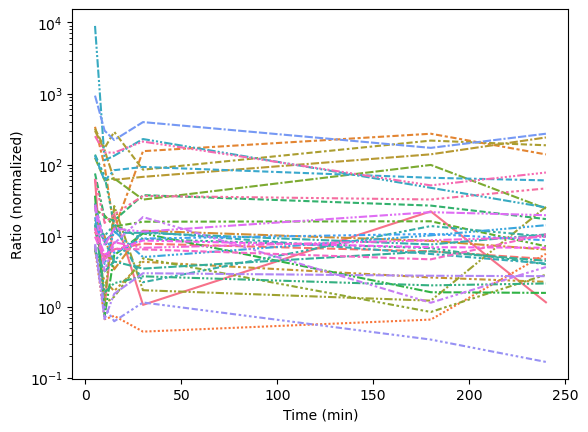

In [22]:
sns.lineplot(data=non_decreasers[non_decreasers['Peak_minutes']==5].iloc[:,1:7].T, legend=False)
plt.yscale('log')
plt.ylabel('Ratio (normalized)')
plt.xlabel('Time (min)')

plt.show()

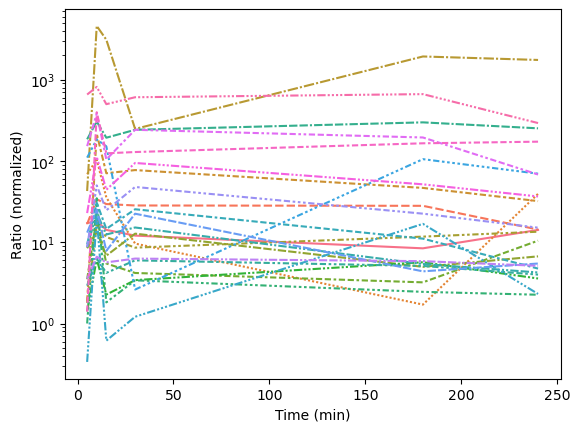

In [23]:
sns.lineplot(data=non_decreasers[non_decreasers['Peak_minutes']==10].iloc[:,1:7].T, legend=False)
plt.yscale('log')
plt.ylabel('Ratio (normalized)')
plt.xlabel('Time (min)')

plt.show()

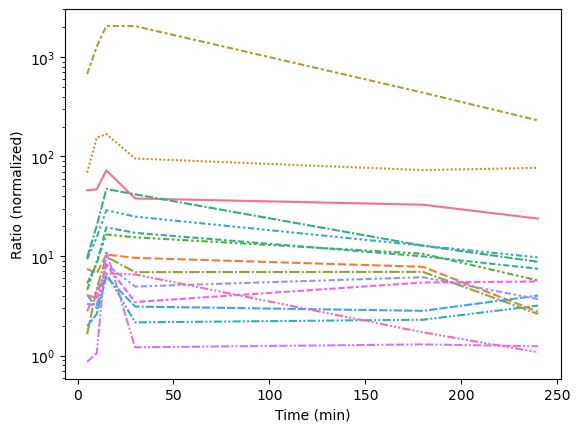

In [30]:
sns.lineplot(data=non_decreasers[non_decreasers['Peak_minutes']==15].iloc[:15,1:7].T, legend=False)
plt.yscale('log')
plt.ylabel('Ratio (normalized)')
plt.xlabel('Time (min)')

plt.show()

# Clustering

In [ ]:
x = pd.read


/global/home/users/empchase/.local/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


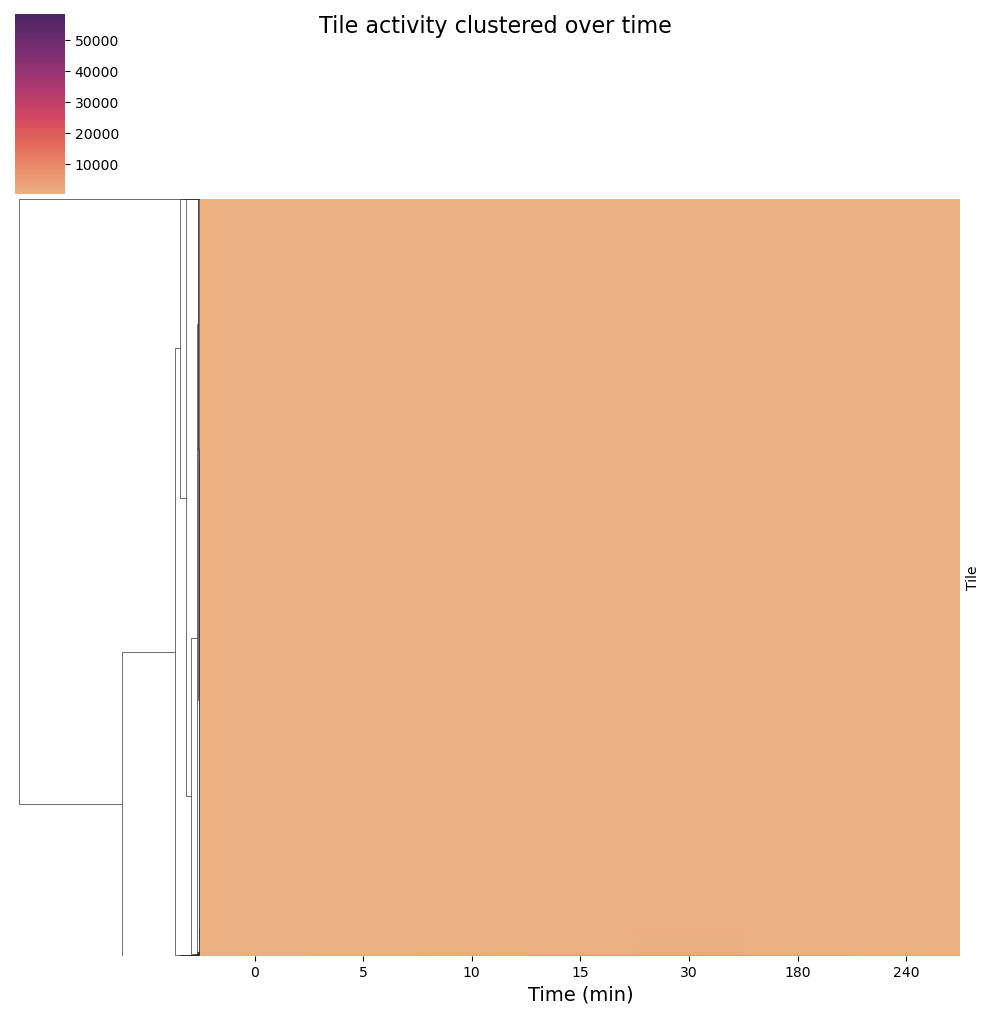

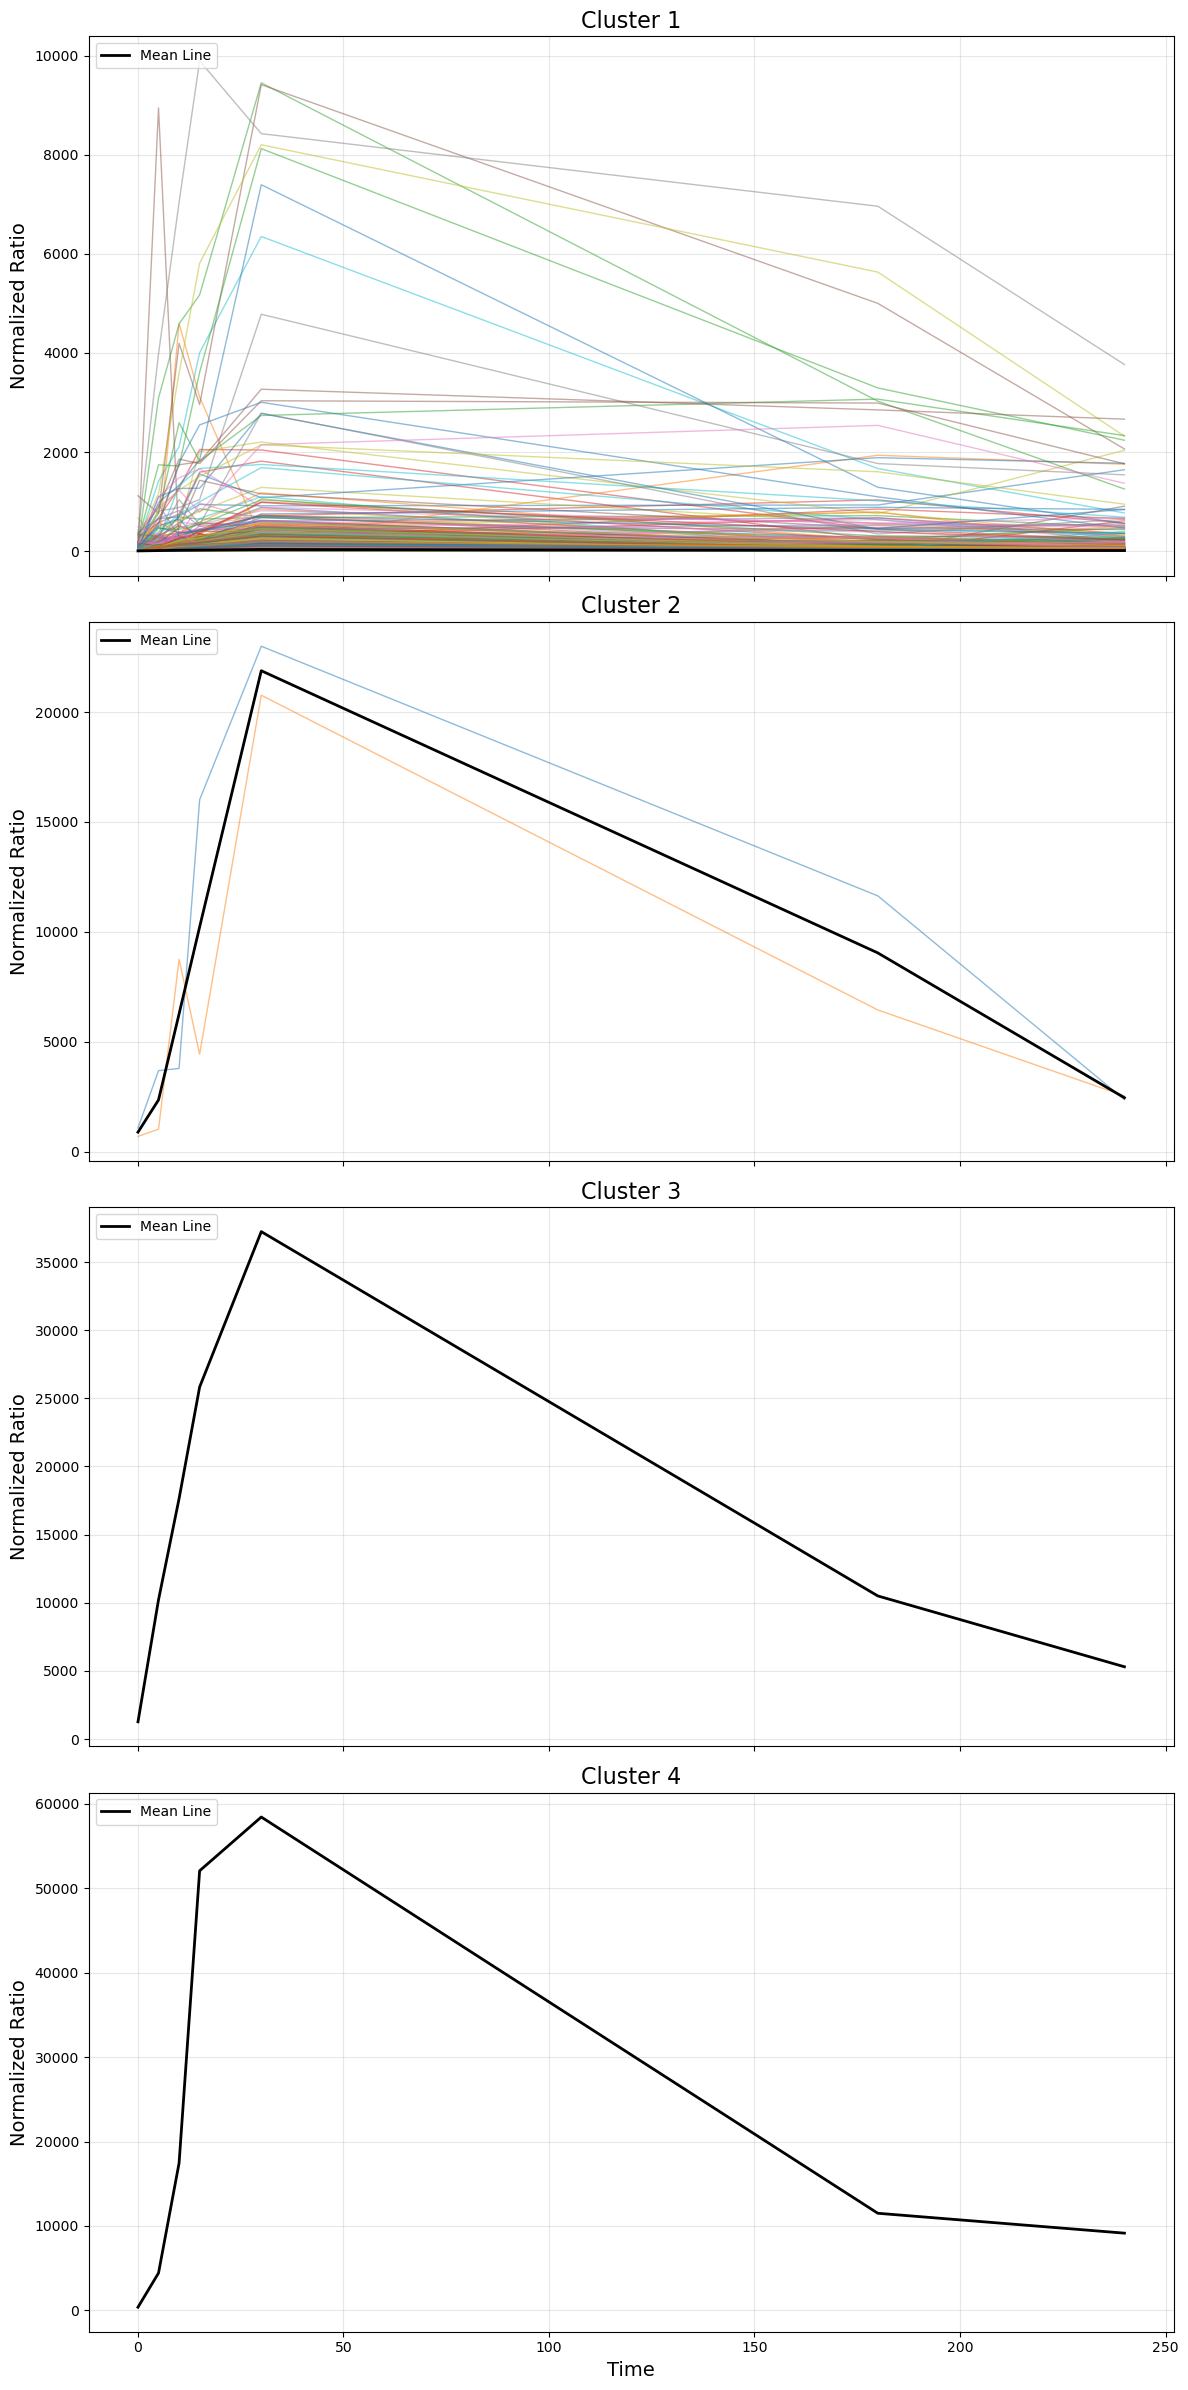

In [39]:

# Step 5: Pivot table
cluster_df = final_means_cat.copy(deep=True)
cluster_df = cluster_df.dropna(axis=0).iloc[:,:7]
# print(cluster_df.head(3))
"""
Time                                                     0         5    \ etc
Tile                                                                     
AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATGA...  0.867888  0.397243   
AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTAA...  0.630991  0.578451   
AAACAAATGTATATTGGTTCTAATAAACCATTGGGTAAAGATCATAG...  1.224115  0.780181  
"""
# t='TTTGTTGCTTCTCCAACATTTAATCATAAATTCTCTTCTTCTAATGCATTTACTACTGAACAAATGAAGACATTTGATCCAGAAGCTGCATTTAATGAATTGTTCTCTCCAGAGTTCTCT'
# cluster_df.loc[t,]



# Step 6: Clustermap
clustermap = sns.clustermap(
    cluster_df, 
    # metric='correlation',
    # z_score = 0,
    # robust=True,
    cmap="flare",  
    col_cluster=False,  
    yticklabels=False, 
    # cbar_kws={"shrink": 0.8}  # Adjust colorbar
)

# Adjust title and labels
clustermap.fig.suptitle('Tile activity clustered over time', fontsize=16)
clustermap.ax_heatmap.set_xlabel('Time (min)', fontsize=14)
# plt.savefig('vp16norm_figs/alldata_clustermap.pdf')
plt.show()


# Step 7: Extract the linkage matrix and determine clusters
linkage_matrix = clustermap.dendrogram_row.linkage
n_clusters = 4  # Define the number of clusters (adjust as needed)
cluster_labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')

# Add cluster labels to the original DataFrame
cluster_df['Cluster'] = cluster_labels

# Step 8: Plot each cluster in a separate subplot
fig, axes = plt.subplots(n_clusters, 1, figsize=(12, 6 * n_clusters), sharex=True)

# Iterate through each cluster and plot the rows
for i in range(1, n_clusters + 1):
    cluster_data = cluster_df[cluster_df['Cluster'] == i].drop(columns=['Cluster'])
    # if i==2:
    #     print(cluster_data.index)
    
    # Plot all rows in the cluster
    for _, row in cluster_data.iterrows():
        axes[i - 1].plot(cluster_data.columns, row.values, alpha=0.5, lw=1)
    
    # Plot the mean line for the cluster
    cluster_mean = cluster_data.mean(axis=0)
    axes[i - 1].plot(cluster_mean.index, cluster_mean.values, color="black", lw=2, label="Mean Line")
    
    # Customize subplot
    axes[i - 1].set_title(f"Cluster {i}", fontsize=16)
    axes[i - 1].set_ylabel("Normalized Ratio", fontsize=14)
    axes[i - 1].grid(alpha=0.3)
    axes[i - 1].legend(loc="upper left")

# Customize x-axis and overall layout
axes[-1].set_xlabel("Time", fontsize=14)
plt.tight_layout()
# plt.savefig('vp16norm_figs/alldata_clusters4.pdf')
plt.show()
